# Load packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pickle
import os
import glob
import re
import lingam
import networkx as nx
import requests
import shap
import warnings
import json
import dice_ml

from sklearn.preprocessing import (
    LabelEncoder,
    StandardScaler,
    MinMaxScaler,
)
from sklearn.metrics import (
    roc_auc_score, 
    roc_curve, 
    confusion_matrix, 
    precision_score, 
    recall_score, 
    accuracy_score,
    classification_report
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from typing import Dict
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import train_test_split
from sklearn.model_selection import TimeSeriesSplit
from sklearn.utils.class_weight import compute_class_weight
from dotenv import load_dotenv
from collections import defaultdict
from IPython.display import display, Markdown
from datetime import datetime
from collections import Counter
from typing import Union

    

load_dotenv()

openai_api_key = os.getenv("OPENAI_API_KEY")
groq_api_key = os.getenv("GROQ_API_KEY")

warnings.filterwarnings('ignore')
print("✅ Imports loaded successfully!")


warnings.filterwarnings('ignore')

✅ Imports loaded successfully!


<br> <br> <br>

# Data Preprocessing

In [2]:
def rows_n_hours_before_failure(machine, machine_failure, hours):  
    failure_times = machine_failure["datetime"]

    # Convert the datetime columns to datetime if they're not already
    machine["datetime"] = pd.to_datetime(machine["datetime"])
    failure_times = pd.to_datetime(failure_times)

    # Initialize an empty list to store the rows and their indices
    rows = []
    indices = []

    # Iterate over each failure time and its index
    for idx_failure, failure_time in zip(machine_failure.index, failure_times):
        # Calculate the time n hours before the failure
        target_time = failure_time - pd.Timedelta(hours=hours)
        
        # Get the row with the closest time to the target time
        idx = (machine["datetime"] - target_time).abs().idxmin()
        closest_row = machine.loc[idx]
        
        # Append the row and the failure index to the lists
        rows.append(closest_row)
        indices.append(idx_failure)

    # Create a new dataframe with the rows
    machine_1_prev_24h = pd.DataFrame(rows)
    machine_1_prev_24h["id_failure_row"] = indices

    return machine_1_prev_24h


def update_lag_failure_target(machine_failure, machine_n_hours_before_failure, lag_failure):
    """
    Updates the 'target' variable in lag_failure with the corresponding 'failure' value from machine_failure,
    using machine_n_hours_before_failure as a bridge for the join.
    """
    if 'id_failure_row' not in machine_n_hours_before_failure.columns:
        raise ValueError("machine_n_hours_before_failure must have 'id_failure_row' column.")

    failure_values = []
    for idx in lag_failure.index:
        if idx in machine_n_hours_before_failure.index:
            id_failure_row = machine_n_hours_before_failure.loc[idx, 'id_failure_row']
            # If multiple rows, take the first
            if isinstance(id_failure_row, pd.Series):
                id_failure_row = id_failure_row.iloc[0]
            failure_val = machine_failure.loc[id_failure_row, 'failure'] if id_failure_row in machine_failure.index else None
        else:
            failure_val = None
        failure_values.append(failure_val)

    lag_failure = lag_failure.copy()
    lag_failure['target'] = failure_values
    return lag_failure


def create_safe_non_failure_samples_enhanced(machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48):
    """
    Create non-failure samples from 'safe zones' using the full feature set from machine_lag
    
    Parameters:
    - machine_lag: Full dataset with all engineered features
    - lag_failure_updated: Your target dataset (24h before failures)
    - hours_before: Lead time before failure (24h)
    - safe_buffer_hours: Additional buffer to ensure truly safe periods (48h recommended)
    """
    
    # Convert datetime columns to datetime if they aren't already
    machine_lag['datetime'] = pd.to_datetime(machine_lag['datetime'])
    lag_failure_updated['datetime'] = pd.to_datetime(lag_failure_updated['datetime'])
    
    # Get all failure timestamps from machine_lag where failure = 1
    failure_timestamps = machine_lag[machine_lag['failure'] == 1]['datetime']
    
    # Create exclusion zones around each failure
    exclusion_periods = []
    
    for failure_time in failure_timestamps:
        # Exclude from (failure_time - safe_buffer_hours) to failure_time
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))
    
    # Also exclude the timestamps that are already in lag_failure_updated (24h before failures)
    existing_target_timestamps = set(lag_failure_updated['datetime'])
    
    # Filter machine_lag to find safe timestamps
    safe_candidates = machine_lag.copy()
    
    # Remove rows that fall in exclusion zones
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False
    
    # Filter out exclusion zones and existing target timestamps
    safe_mask = (
        ~safe_candidates['datetime'].apply(is_in_exclusion_zone) &
        ~safe_candidates['datetime'].isin(existing_target_timestamps) &
        (safe_candidates['failure'] == 0)  # Only non-failure records
    )
    
    safe_candidates = safe_candidates[safe_mask]
    
    if len(safe_candidates) == 0:
        print("Warning: No safe candidates found. Consider reducing safe_buffer_hours.")
        return pd.DataFrame()
    
    # Sample non-failure records
    n_samples = min(len(lag_failure_updated), len(safe_candidates))
    
    if n_samples > len(safe_candidates):
        print(f"Warning: Only {len(safe_candidates)} safe candidates available, but {len(lag_failure_updated)} samples requested.")
        n_samples = len(safe_candidates)
    
    # Randomly sample from safe candidates
    non_failure_samples = safe_candidates.sample(n=n_samples, random_state=42).copy()
    
    # Set target to 0 for non-failure samples (they should already be 0, but ensure it)
    non_failure_samples['target'] = 0
    
    # Reset index
    non_failure_samples = non_failure_samples.reset_index(drop=True)
    
    return non_failure_samples

def create_balanced_dataset(machine_lag, lag_failure_updated, hours_before=24, safe_buffer_hours=48):
    """
    Create a balanced dataset combining failure predictions and safe non-failure samples
    """
    
    # Get non-failure samples
    non_failure_df = create_safe_non_failure_samples_enhanced(machine_lag, lag_failure_updated, hours_before, safe_buffer_hours)
    
    if len(non_failure_df) == 0:
        return lag_failure_updated.copy()
    
    # Ensure both dataframes have the same columns
    common_columns = list(set(lag_failure_updated.columns) & set(non_failure_df.columns))
    
    # If lag_failure_updated is missing some features, we need to merge them from machine_lag
    if len(common_columns) < len(machine_lag.columns):
        print("Merging additional features from machine_lag to lag_failure_updated...")
        
        # Merge lag_failure_updated with machine_lag to get all features
        lag_failure_enhanced = pd.merge(
            lag_failure_updated, 
            machine_lag, 
            on='datetime', 
            how='left',
            suffixes=('', '_from_machine_lag')
        )
        
        # Clean up duplicate columns (keep the original values from lag_failure_updated)
        for col in lag_failure_enhanced.columns:
            if col.endswith('_from_machine_lag'):
                original_col = col.replace('_from_machine_lag', '')
                if original_col in lag_failure_enhanced.columns:
                    lag_failure_enhanced[original_col] = lag_failure_enhanced[original_col].fillna(
                        lag_failure_enhanced[col]
                    )
                    lag_failure_enhanced = lag_failure_enhanced.drop(columns=[col])
        
        lag_failure_to_use = lag_failure_enhanced
    else:
        lag_failure_to_use = lag_failure_updated.copy()
    
    # Ensure all required columns are present in both dataframes
    all_required_columns = list(machine_lag.columns)
    
    # Add missing columns with appropriate default values if needed
    for col in all_required_columns:
        if col not in lag_failure_to_use.columns:
            lag_failure_to_use[col] = np.nan
        if col not in non_failure_df.columns:
            non_failure_df[col] = np.nan
    
    # Select only the required columns in the same order
    lag_failure_to_use = lag_failure_to_use[all_required_columns]
    non_failure_df = non_failure_df[all_required_columns]
    
    # Combine datasets
    balanced_dataset = pd.concat([lag_failure_to_use, non_failure_df], ignore_index=True)
    balanced_dataset = balanced_dataset.sort_values('datetime').reset_index(drop=True)
    
    return balanced_dataset, non_failure_df


# Alternative: If you want more control over sampling strategy
def create_stratified_non_failure_samples(machine_lag, lag_failure_updated, safe_buffer_hours=48, stratify_by=['comp', 'is_weekend', 'is_working_hours']):
    """
    Create stratified non-failure samples to ensure diversity across different conditions
    """
    
    machine_lag['datetime'] = pd.to_datetime(machine_lag['datetime'])
    lag_failure_updated['datetime'] = pd.to_datetime(lag_failure_updated['datetime'])
    
    # Get failure timestamps and create exclusion zones
    failure_timestamps = machine_lag[machine_lag['failure'] == 1]['datetime']
    exclusion_periods = []
    
    for failure_time in failure_timestamps:
        start_exclusion = failure_time - pd.Timedelta(hours=safe_buffer_hours)
        end_exclusion = failure_time
        exclusion_periods.append((start_exclusion, end_exclusion))
    
    # Filter safe candidates
    def is_in_exclusion_zone(timestamp):
        for start_excl, end_excl in exclusion_periods:
            if start_excl <= timestamp <= end_excl:
                return True
        return False
    
    existing_target_timestamps = set(lag_failure_updated['datetime'])
    
    safe_mask = (
        ~machine_lag['datetime'].apply(is_in_exclusion_zone) &
        ~machine_lag['datetime'].isin(existing_target_timestamps) &
        (machine_lag['failure'] == 0)
    )
    
    safe_candidates = machine_lag[safe_mask].copy()
    
    if len(safe_candidates) == 0:
        return pd.DataFrame()
    
    # Stratified sampling
    target_samples = len(lag_failure_updated)
    
    # Get the distribution of stratification variables in lag_failure_updated
    if all(col in lag_failure_updated.columns for col in stratify_by):
        # Sample proportionally to match the failure sample distribution
        stratified_samples = []
        
        for group_values, group_df in lag_failure_updated.groupby(stratify_by):
            group_size = len(group_df)
            proportion = group_size / len(lag_failure_updated)
            target_group_size = int(proportion * target_samples)
            
            # Find matching safe candidates
            mask = pd.Series(True, index=safe_candidates.index)
            for i, col in enumerate(stratify_by):
                mask &= (safe_candidates[col] == group_values[i])
            
            group_safe_candidates = safe_candidates[mask]
            
            if len(group_safe_candidates) > 0:
                sample_size = min(target_group_size, len(group_safe_candidates))
                group_sample = group_safe_candidates.sample(n=sample_size, random_state=42)
                stratified_samples.append(group_sample)
        
        if stratified_samples:
            non_failure_samples = pd.concat(stratified_samples, ignore_index=True)
        else:
            # Fallback to random sampling
            non_failure_samples = safe_candidates.sample(
                n=min(target_samples, len(safe_candidates)), 
                random_state=42
            )
    else:
        # Fallback to random sampling if stratification columns not available
        non_failure_samples = safe_candidates.sample(
            n=min(target_samples, len(safe_candidates)), 
            random_state=42
        )
    
    non_failure_samples['target'] = 0
    
    return non_failure_samples.reset_index(drop=True)

In [3]:
# Loop through machine_number 1 to 100 and generate balanced datasets for each machine

hours_before_failure = 1
safe_buffer_hours = 72

balanced_datasets = {}
non_failure_dfs = {}

for machine_number in range(1, 101):
    try:
        # Load data for this machine
        machine = pd.read_csv(f"../../data/azure_pm/machines/machine_{machine_number}.csv")
        machine_lag = pd.read_csv(f"../../data/azure_pm/lag_features/machine_{machine_number}_lag_features.csv")

        # Identify failures
        machine_failure = machine[machine['failure'] != '0']

        # Get rows n hours before each failure
        machine_n_hours_before_failure = rows_n_hours_before_failure(machine=machine,machine_failure=machine_failure,hours=hours_before_failure)
        lag_failure = rows_n_hours_before_failure(machine=machine_lag,machine_failure=machine_lag[machine_lag['failure'] != 0], hours=hours_before_failure)

        # Update lag_failure target
        lag_failure_updated = update_lag_failure_target(machine_failure=machine_failure, machine_n_hours_before_failure=machine_n_hours_before_failure, lag_failure=lag_failure)

        # Create balanced dataset
        balanced_dataset, non_failure_df = create_balanced_dataset(machine_lag=machine_lag, 
                                                                   lag_failure_updated=lag_failure_updated, 
                                                                   hours_before=hours_before_failure, 
                                                                   safe_buffer_hours=safe_buffer_hours)

        # Store results with machine number as key
        balanced_datasets[machine_number] = balanced_dataset
        non_failure_dfs[machine_number] = non_failure_df

        print(f"✅ Machine {machine_number}: Balanced dataset shape: {balanced_dataset.shape}, Non-failure shape: {non_failure_df.shape}")

    except Exception as e:
        print(f"❌ Machine {machine_number}: Error - {e}")

✅ Machine 1: Balanced dataset shape: (22, 68), Non-failure shape: (11, 68)
✅ Machine 2: Balanced dataset shape: (12, 68), Non-failure shape: (6, 68)
✅ Machine 3: Balanced dataset shape: (10, 68), Non-failure shape: (5, 68)
✅ Machine 4: Balanced dataset shape: (14, 68), Non-failure shape: (7, 68)
✅ Machine 5: Balanced dataset shape: (20, 68), Non-failure shape: (10, 68)
❌ Machine 6: Error - 'datetime'
✅ Machine 7: Balanced dataset shape: (34, 68), Non-failure shape: (17, 68)
✅ Machine 8: Balanced dataset shape: (10, 68), Non-failure shape: (5, 68)
✅ Machine 9: Balanced dataset shape: (32, 68), Non-failure shape: (16, 68)
✅ Machine 10: Balanced dataset shape: (16, 68), Non-failure shape: (8, 68)
✅ Machine 11: Balanced dataset shape: (18, 68), Non-failure shape: (9, 68)
✅ Machine 12: Balanced dataset shape: (18, 68), Non-failure shape: (9, 68)
✅ Machine 13: Balanced dataset shape: (44, 68), Non-failure shape: (22, 68)
✅ Machine 14: Balanced dataset shape: (14, 68), Non-failure shape: (7, 

In [4]:
# Join all balanced_datasets into a single DataFrame named df_union
df_union = pd.concat(
    [df for df in balanced_datasets.values() if not df.empty],
    ignore_index=True
)

# Optional: sort by datetime and reset index for consistency
df_union = df_union.sort_values(by='datetime').reset_index(drop=True)

df = df_union.copy()

# Apply mapping to target column so it's always integer
target_mapping = {
    "0": 0,
    0: 0,
    "comp1": 1,
    1: 1,
    "comp2": 2,
    2: 2,
    "comp3": 3,
    3: 3,
    "comp4": 4,
    4: 4
}
df["target"] = df["target"].map(target_mapping).astype(int)

In [5]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,...,error_count_6h,error_count_24h,maint_count_6h,maint_count_24h,hour,day_of_week,is_weekend,is_working_hours,hours_since_maint,hours_since_error
0,2015-01-01 20:00:00,21,0.510555,0.319933,0.376847,0.355634,model2,14,0,0,...,0.0,0.0,0.0,0.0,20,3,0,0,14,14
1,2015-01-01 20:00:00,85,0.525555,0.489049,0.507522,0.719747,model1,16,0,0,...,0.0,0.0,0.0,0.0,20,3,0,0,14,14
2,2015-01-01 20:00:00,23,0.644100,0.464922,0.459205,0.392635,model1,17,0,0,...,0.0,0.0,0.0,0.0,20,3,0,0,14,14
3,2015-01-01 20:00:00,37,0.524530,0.532051,0.351415,0.465700,model1,16,0,0,...,0.0,0.0,0.0,0.0,20,3,0,0,14,14
4,2015-01-02 02:00:00,22,0.716302,0.628508,0.380510,0.407093,model1,14,0,0,...,0.0,0.0,0.0,0.0,2,4,0,0,20,20


<br> <br> <br>

Remove columns

In [6]:
df.drop(columns=['comp_lag_1h',
                 'comp_lag_6h', 
                 'comp_lag_12h', 
                 'maint_count_6h', 
                 'maint_count_24h', 
                 'hour', 
                 'day_of_week', 
                 'is_weekend', 
                 'is_working_hours', 
                 'hours_since_maint', 
                 'hours_since_error'
                 ], inplace=True)


df.columns

Index(['datetime', 'machineID', 'volt', 'rotate', 'pressure', 'vibration',
       'model', 'age', 'errorID', 'comp', 'failure', 'target', 'volt_lag_1h',
       'volt_lag_6h', 'volt_lag_12h', 'volt_lag_24h', 'volt_mean_24h',
       'volt_std_24h', 'volt_min_24h', 'volt_max_24h', 'volt_mean_6h',
       'volt_std_6h', 'rotate_lag_1h', 'rotate_lag_6h', 'rotate_lag_12h',
       'rotate_lag_24h', 'rotate_mean_24h', 'rotate_std_24h', 'rotate_min_24h',
       'rotate_max_24h', 'rotate_mean_6h', 'rotate_std_6h', 'pressure_lag_1h',
       'pressure_lag_6h', 'pressure_lag_12h', 'pressure_lag_24h',
       'pressure_mean_24h', 'pressure_std_24h', 'pressure_min_24h',
       'pressure_max_24h', 'pressure_mean_6h', 'pressure_std_6h',
       'vibration_lag_1h', 'vibration_lag_6h', 'vibration_lag_12h',
       'vibration_lag_24h', 'vibration_mean_24h', 'vibration_std_24h',
       'vibration_min_24h', 'vibration_max_24h', 'vibration_mean_6h',
       'vibration_std_6h', 'errorID_lag_1h', 'errorID_lag_6h',


In [7]:
df.head()

,datetime,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
0,2015-01-01 20:00:00,21,0.510555,0.319933,0.376847,0.355634,model2,14,0,0,...,0.085272,0.272477,0.593755,0.390611,0.094780,0.0,0.0,0.0,0.0,0.0
1,2015-01-01 20:00:00,85,0.525555,0.489049,0.507522,0.719747,model1,16,0,0,...,0.139035,0.182899,0.719747,0.407149,0.175328,0.0,0.0,0.0,0.0,0.0
2,2015-01-01 20:00:00,23,0.644100,0.464922,0.459205,0.392635,model1,17,0,0,...,0.101053,0.278771,0.596488,0.464398,0.088249,0.0,0.0,0.0,0.0,0.0
3,2015-01-01 20:00:00,37,0.524530,0.532051,0.351415,0.465700,model1,16,0,0,...,0.186134,0.084803,0.775051,0.445911,0.064274,0.0,0.0,0.0,0.0,0.0
4,2015-01-02 02:00:00,22,0.716302,0.628508,0.380510,0.407093,model1,14,0,0,...,0.104372,0.152847,0.582784,0.321240,0.125673,0.0,0.0,0.0,0.0,0.0


<br> <br> <br>

---

<br> <br>

<br> <br> <br>

# Machine Learning

In [8]:
# Convert df["model"] to numeric in-place.
# Strategy: try direct numeric conversion -> extract trailing digits -> fallback to LabelEncoder.

try:
    df['model'] = pd.to_numeric(df['model'])
except Exception:
    digits = df['model'].astype(str).str.extract(r'(\d+)')
    if not digits.isnull().values.any():
        df['model'] = digits[0].astype(int)
    else:
        le = LabelEncoder()
        df['model'] = le.fit_transform(df['model'].astype(str))

print("Unique model values after conversion:", df['model'].unique())

Unique model values after conversion: [2 1 3 4]


In [9]:
df["target"]

0       0
1       0
2       0
3       0
4       1
       ..
2239    4
2240    1
2241    1
2242    0
2243    0
Name: target, Length: 2244, dtype: int32

Dataset shape: (2244, 57)
Feature columns: 54

Train set shape: (1795, 54)
Test set shape: (449, 54)

Training RandomForest...
RandomForest - ROC AUC (macro): 0.9952, Accuracy: 0.9555
Training XGBoost...
XGBoost - ROC AUC (macro): 0.9962, Accuracy: 0.9488
Training LightGBM...
LightGBM - ROC AUC (macro): 0.9959, Accuracy: 0.9265
Training CatBoost...
0:	learn: 1.5556100	total: 149ms	remaining: 14.8s
99:	learn: 0.2566197	total: 6.39s	remaining: 0us
CatBoost - ROC AUC (macro): 0.9933, Accuracy: 0.3093

DETAILED EVALUATION RESULTS

SUMMARY OF ALL METRICS:
       Model ROC_AUC_macro ROC_AUC_micro Normalized_AUC Youden_Index Precision_macro Precision_micro Recall_macro Recall_micro Accuracy ROC_AUC_class2 Normalized_AUC_class2 Youden_Index_class2 Precision_class2 Recall_class2
RandomForest        0.9952        0.9963         0.9904       0.9280          0.9475          0.9555       0.9401       0.9555   0.9555         0.9942                0.9884              0.9268           0.8936        0.

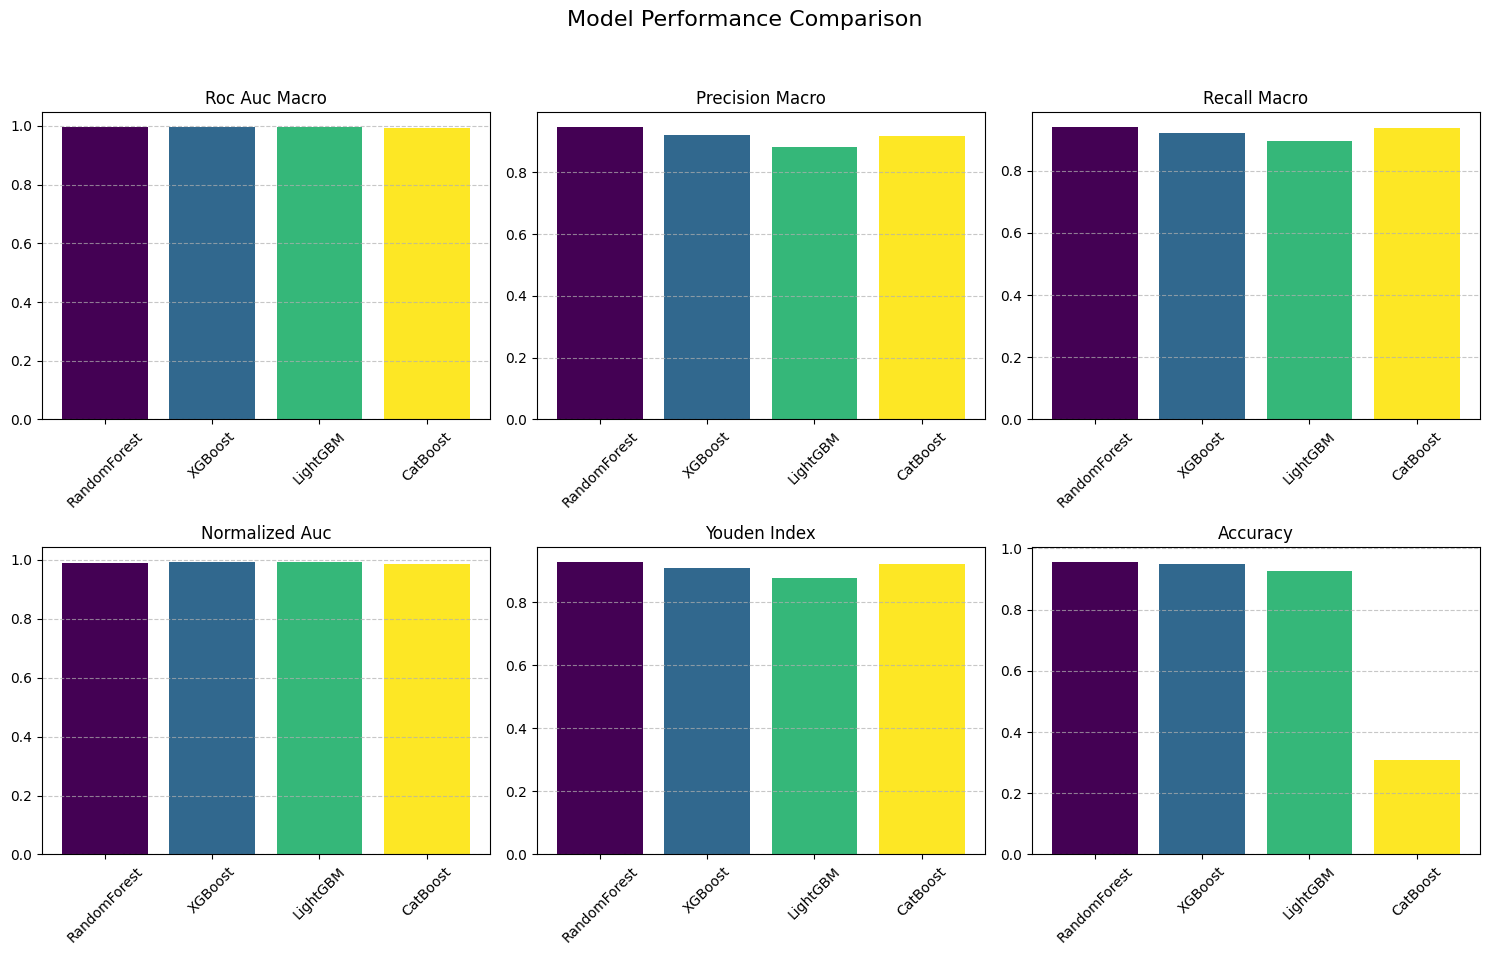

In [10]:
class MultiClassPredictiveMaintenanceEvaluator:
    """
    Comprehensive evaluator for multi-class predictive maintenance models.
    """

    def __init__(self, random_state=42):
        self.random_state = random_state
        self.models = {}
        self.results = {}

    def prepare_data(self, df, test_size=0.2, target_col='target', excluded_column = ['datetime', 'failure', 'target']):
        """
        Prepare and split data, ensuring temporal sequence and correct data formats.
        """
        df['datetime'] = pd.to_datetime(df['datetime'])
        df = df.sort_values(by='datetime').reset_index(drop=True)

        # exclude_cols = ['datetime', 'failure', 'target']
        exclude_cols = excluded_column
        feature_cols = [col for col in df.columns if col not in exclude_cols]
        X = df[feature_cols].fillna(0)
        y = df[target_col]

        split_index = int(len(df) * (1 - test_size))
        X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
        y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

        # Convert y_train and y_test to 1D NumPy arrays to ensure compatibility
        y_train = y_train.values
        y_test = y_test.values

        print(f"Dataset shape: {df.shape}")
        print(f"Feature columns: {len(feature_cols)}")
        print(f"\nTrain set shape: {X_train.shape}")
        print(f"Test set shape: {X_test.shape}\n")

        return X_train, X_test, y_train, y_test

    def initialize_models(self):
        """
        Initialize all machine learning models.
        """
        self.models = {
            'RandomForest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=self.random_state, n_jobs=-1),
            'XGBoost': XGBClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, eval_metric='mlogloss'),
            'LightGBM': LGBMClassifier(n_estimators=100, max_depth=6, random_state=self.random_state, verbose=-1),
            'CatBoost': CatBoostClassifier(iterations=100, depth=8, learning_rate=0.03,l2_leaf_reg=5, auto_class_weights="Balanced" ,random_seed=self.random_state, verbose=100)
        }

    def calculate_metrics(self, y_true, y_pred, y_pred_proba):
        """
        Calculate comprehensive metrics for multi-class classification.
        """
        metrics = {}
        classes = np.unique(y_true)
        
        # 1. ROC AUC (macro and micro)
        metrics['ROC_AUC_macro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
        metrics['ROC_AUC_micro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='micro')

        # 2. Normalized AUC
        per_class_aucs = [roc_auc_score(y_true == c, y_pred_proba[:, i]) for i, c in enumerate(classes)]
        metrics['Normalized_AUC'] = np.mean([(auc - 0.5) / 0.5 for auc in per_class_aucs])

        # 3. Youden Index
        youden_scores = []
        for i, c in enumerate(classes):
            y_true_binary = (y_true == c)
            y_pred_binary = (y_pred == c)
            tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            youden_scores.append(sensitivity + specificity - 1)
        metrics['Youden_Index'] = np.mean(youden_scores)
        
        # 4. Precision (macro and micro)
        metrics['Precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Precision_micro'] = precision_score(y_true, y_pred, average='micro', zero_division=0)

        # 5. Recall (macro and micro)
        metrics['Recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Recall_micro'] = recall_score(y_true, y_pred, average='micro', zero_division=0)
        
        metrics['Accuracy'] = np.mean(y_true == y_pred)
        return metrics

    def train_and_evaluate(self, X_train, X_test, y_train, y_test):
        """
        Train all models and evaluate their performance.
        """
        X_train.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_train.columns]
        X_test.columns = [re.sub(r'[^A-Za-z0-9_]+', '', str(col)) for col in X_test.columns]

        self.initialize_models()
        self.results = {}

        for model_name, model in self.models.items():
            print(f"Training {model_name}...")
            model.fit(X_train, y_train)

            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)
            metrics = self.calculate_metrics(y_test, y_pred, y_pred_proba)

            self.results[model_name] = {'metrics': metrics, 'y_pred': y_pred}
            print(f"{model_name} - ROC AUC (macro): {metrics['ROC_AUC_macro']:.4f}, Accuracy: {metrics['Accuracy']:.4f}")

    def print_detailed_results(self, y_test):
        """
        Print detailed classification reports and confusion matrices.
        """
        print("\n" + "="*80 + "\nDETAILED EVALUATION RESULTS\n" + "="*80)
        summary_data = [{'Model': name, **{k: f"{v:.4f}" for k, v in res['metrics'].items()}}
                        for name, res in self.results.items()]
        
        print("\nSUMMARY OF ALL METRICS:")
        print(pd.DataFrame(summary_data).to_string(index=False))

        for model_name, result in self.results.items():
            print(f"\n{'-'*60}\nDETAILED RESULTS FOR {model_name}\n{'-'*60}")
            print("Classification Report:\n", classification_report(y_test, result['y_pred']))
            print("Confusion Matrix:\n", confusion_matrix(y_test, result['y_pred']))

    def plot_results(self, figsize=(15, 10)):
        """
        Create and display visualizations of model performance.
        """
        fig, axes = plt.subplots(2, 3, figsize=figsize)
        fig.suptitle('Model Performance Comparison', fontsize=16)
        axes = axes.ravel()
        
        metrics_to_plot = ['ROC_AUC_macro', 'Precision_macro', 'Recall_macro', 'Normalized_AUC', 'Youden_Index', 'Accuracy']
        model_names = list(self.results.keys())

        for i, metric in enumerate(metrics_to_plot):
            ax = axes[i]
            scores = [self.results[model]['metrics'][metric] for model in model_names]
            ax.bar(model_names, scores, color=plt.cm.viridis(np.linspace(0, 1, len(model_names))))
            ax.set_title(metric.replace('_', ' ').title())
            ax.tick_params(axis='x', labelrotation=45)
            ax.grid(axis='y', linestyle='--', alpha=0.7)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        plt.show()

    
    def calculate_metrics(self, y_true, y_pred, y_pred_proba):
        """
        Calculate comprehensive metrics for multi-class classification.
        Also compute binary (one-vs-rest) metrics for class '2' when available:
          - ROC AUC (binary for class 2)
          - Normalized AUC (binary for class 2)
          - Youden Index (binary for class 2)
          - Precision / Recall (binary for class 2)
        """
        metrics = {}
        classes = np.unique(y_true)

        # Multi-class ROC AUC (OVR) — guard with try/except
        try:
            metrics['ROC_AUC_macro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='macro')
            metrics['ROC_AUC_micro'] = roc_auc_score(y_true, y_pred_proba, multi_class='ovr', average='micro')
        except Exception:
            metrics['ROC_AUC_macro'] = np.nan
            metrics['ROC_AUC_micro'] = np.nan

        # Per-class AUCs (safe)
        per_class_aucs = []
        for i, c in enumerate(classes):
            try:
                auc_val = roc_auc_score((y_true == c).astype(int), y_pred_proba[:, i])
            except Exception:
                auc_val = np.nan
            per_class_aucs.append(auc_val)

        # Normalized AUC: mean of (auc - 0.5)/0.5 across available per-class AUCs
        normalized_values = [(auc - 0.5) / 0.5 for auc in per_class_aucs if not np.isnan(auc)]
        metrics['Normalized_AUC'] = np.nanmean(normalized_values) if normalized_values else np.nan

        # Youden Index per class (safe)
        youden_scores = []
        for i, c in enumerate(classes):
            try:
                y_true_bin = (y_true == c).astype(int)
                y_pred_bin = (y_pred == c).astype(int)
                tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                youden_scores.append(sensitivity + specificity - 1)
            except Exception:
                youden_scores.append(np.nan)
        valid_youden = [s for s in youden_scores if not np.isnan(s)]
        metrics['Youden_Index'] = np.nanmean(valid_youden) if valid_youden else np.nan

        # Precision & Recall (macro & micro)
        metrics['Precision_macro'] = precision_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Precision_micro'] = precision_score(y_true, y_pred, average='micro', zero_division=0)
        metrics['Recall_macro'] = recall_score(y_true, y_pred, average='macro', zero_division=0)
        metrics['Recall_micro'] = recall_score(y_true, y_pred, average='micro', zero_division=0)

        # Accuracy
        metrics['Accuracy'] = np.mean(y_true == y_pred)

        # Binary one-vs-rest metrics specifically for class '2' (if present)
        class_of_interest = 2
        if class_of_interest in classes:
            # find index of class 2 in classes ordering (aligns with y_pred_proba columns)
            class_index = list(classes).index(class_of_interest)
            y_true_bin = (y_true == class_of_interest).astype(int)
            y_pred_bin = (y_pred == class_of_interest).astype(int)

            # ROC AUC for class 2 (binary), normalized AUC
            try:
                auc_class2 = roc_auc_score(y_true_bin, y_pred_proba[:, class_index])
                metrics['ROC_AUC_class2'] = auc_class2
                metrics['Normalized_AUC_class2'] = (auc_class2 - 0.5) / 0.5
            except Exception:
                metrics['ROC_AUC_class2'] = np.nan
                metrics['Normalized_AUC_class2'] = np.nan

            # Youden Index for class 2
            try:
                tn, fp, fn, tp = confusion_matrix(y_true_bin, y_pred_bin).ravel()
                sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
                specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
                metrics['Youden_Index_class2'] = sensitivity + specificity - 1
            except Exception:
                metrics['Youden_Index_class2'] = np.nan

            # Precision / Recall for class 2 (binary)
            metrics['Precision_class2'] = precision_score(y_true_bin, y_pred_bin, zero_division=0)
            metrics['Recall_class2'] = recall_score(y_true_bin, y_pred_bin, zero_division=0)
        else:
            # Fill keys with NaN when class 2 not present
            metrics['ROC_AUC_class2'] = np.nan
            metrics['Normalized_AUC_class2'] = np.nan
            metrics['Youden_Index_class2'] = np.nan
            metrics['Precision_class2'] = np.nan
            metrics['Recall_class2'] = np.nan

        return metrics




excluded_columns = ['datetime', 'failure', 'target'] 


def run_complete_evaluation(df):
    """
    Run the complete evaluation pipeline.
    """
    evaluator = MultiClassPredictiveMaintenanceEvaluator(random_state=42)
    X_train, X_test, y_train, y_test = evaluator.prepare_data(df=df, excluded_column = excluded_columns)
    evaluator.train_and_evaluate(X_train, X_test, y_train, y_test)
    evaluator.print_detailed_results(y_test)
    evaluator.plot_results()
    return evaluator, X_test, y_test, X_train, y_train

# --- Main Execution ---
# df = pd.read_csv("../../data/azure_pm/balanced_dataset_safezone/merged_dataset/balanced_azure_pm.csv")
evaluator_results, X_test, y_test, X_train, y_train = run_complete_evaluation(df)

In [11]:
# 1) get a model (from evaluator instance)
model = evaluator_results.models['RandomForest']  

# 2) compute predictions on X_test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)   # shape: (n_samples, n_classes)

# 3) call calculate_metrics
metrics = evaluator_results.calculate_metrics(y_test, y_pred, y_pred_proba)

# 4) view results
metrics

{'ROC_AUC_macro': 0.9952061228769686,
 'ROC_AUC_micro': 0.9963368237260728,
 'Normalized_AUC': 0.9904122457539369,
 'Youden_Index': 0.9280295772217052,
 'Precision_macro': 0.9474934861249291,
 'Precision_micro': 0.955456570155902,
 'Recall_macro': 0.9400653006903006,
 'Recall_micro': 0.955456570155902,
 'Accuracy': 0.955456570155902,
 'ROC_AUC_class2': 0.9942080080584236,
 'Normalized_AUC_class2': 0.9884160161168472,
 'Youden_Index_class2': 0.9268446235205239,
 'Precision_class2': 0.8936170212765957,
 'Recall_class2': 0.9545454545454546}

In [12]:
# 1) get a model (from evaluator instance)
model = evaluator_results.models['XGBoost']   # or 'RandomForest','LightGBM','CatBoost'

# 2) compute predictions on X_test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)   # shape: (n_samples, n_classes)

# 3) call calculate_metrics
metrics = evaluator_results.calculate_metrics(y_test, y_pred, y_pred_proba)

# 4) view results
metrics

{'ROC_AUC_macro': 0.9961675167260505,
 'ROC_AUC_micro': 0.9974714907168118,
 'Normalized_AUC': 0.992335033452101,
 'Youden_Index': 0.9076490972279643,
 'Precision_macro': 0.9207654559835422,
 'Precision_micro': 0.9487750556792873,
 'Recall_macro': 0.9203331578331578,
 'Recall_micro': 0.9487750556792873,
 'Accuracy': 0.9487750556792873,
 'ROC_AUC_class2': 0.9969466129438429,
 'Normalized_AUC_class2': 0.9938932258876858,
 'Youden_Index_class2': 0.9296147066230169,
 'Precision_class2': 0.9032258064516129,
 'Recall_class2': 0.9545454545454546}

In [13]:
# 1) get a model (from evaluator instance)
model = evaluator_results.models['LightGBM']  

# 2) compute predictions on X_test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)   # shape: (n_samples, n_classes)

# 3) call calculate_metrics
metrics = evaluator_results.calculate_metrics(y_test, y_pred, y_pred_proba)

# 4) view results
metrics

{'ROC_AUC_macro': 0.9959299815382654,
 'ROC_AUC_micro': 0.996862614768776,
 'Normalized_AUC': 0.9918599630765306,
 'Youden_Index': 0.8759546040258283,
 'Precision_macro': 0.8815228467704191,
 'Precision_micro': 0.9265033407572383,
 'Recall_macro': 0.8935149760149761,
 'Recall_micro': 0.9265033407572383,
 'Accuracy': 0.9265033407572383,
 'ROC_AUC_class2': 0.9966633089901789,
 'Normalized_AUC_class2': 0.9933266179803577,
 'Youden_Index_class2': 0.8927537144296147,
 'Precision_class2': 0.8901098901098901,
 'Recall_class2': 0.9204545454545454}

In [14]:
# 1) get a model (from evaluator instance)
model = evaluator_results.models['CatBoost']  

# 2) compute predictions on X_test
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)   # shape: (n_samples, n_classes)

# 3) call calculate_metrics
metrics = evaluator_results.calculate_metrics(y_test, y_pred, y_pred_proba)

# 4) view results
metrics

{'ROC_AUC_macro': 0.9933260050869478,
 'ROC_AUC_micro': 0.9924243927361471,
 'Normalized_AUC': 0.9866520101738956,
 'Youden_Index': 0.9216607714356378,
 'Precision_macro': 0.9167353988779418,
 'Precision_micro': 0.9420935412026726,
 'Recall_macro': 0.9355121680121681,
 'Recall_micro': 0.9420935412026726,
 'Accuracy': 0.30928914043085104,
 'ROC_AUC_class2': 0.9935154872828003,
 'Normalized_AUC_class2': 0.9870309745656005,
 'Youden_Index_class2': 0.9182510702593807,
 'Precision_class2': 0.9021739130434783,
 'Recall_class2': 0.9431818181818182}

<br> <br>

CatBoost accuracy is much lower than other ML models because of one or more of the following reasons:

- **Class imbalance handling:** CatBoost may not be configured with the correct class weights or balancing strategy for your multi-class, imbalanced dataset. The other models (RandomForest, LightGBM, XGBoost) have explicit parameters for class weighting (`class_weight`, `scale_pos_weight`, etc.), but CatBoost requires `class_weights` or `auto_class_weights='Balanced'` for proper balancing.
- **Hyperparameter settings:** The default hyperparameters for CatBoost (e.g., `iterations`, `depth`, `learning_rate`) may not be optimal for your data, while the other models might be better tuned.
- **Feature preprocessing:** CatBoost handles categorical features natively, but if your features are already encoded or not properly specified, it may not leverage its strengths.
- **Random seed or data split:** If the random seed or train/test split is not consistent, CatBoost may be affected more due to its internal handling of randomness.
- **Implementation bug:** There could be a bug in how CatBoost is initialized or trained in your pipeline. For example, if the target labels are not correctly mapped or if the training data is not properly shuffled.

To improve CatBoost accuracy, check:
- That you set `auto_class_weights='Balanced'` or provide explicit `class_weights` for imbalanced data.
- That your target labels are correctly mapped and encoded.
- That you tune CatBoost hyperparameters.
- That you use the same train/test split and preprocessing for all models.

You can review the CatBoost initialization in your code at `MultiClassPredictiveMaintenanceEvaluator` for possible improvements.

In [15]:
# Save each model as a .pkl file

# model_save_path = "../../model/azure_pm/balanced_model/"
model_save_path = "models/"

for model_name, model in evaluator_results.models.items():
    with open(f"{model_save_path}{model_name}.pkl", "wb") as f:
          pickle.dump(model, f)          

<br> <br>

---

<br> <br> <br>


# Causality

In [16]:
def create_causal_network(df, features, regularize=True, noise_level=1e-4, self_reference=True):
    """
    Build a causal network from VARLiNGAM adjacency matrices.

    Args:
      df: dataframe with data
      features: list of feature names (order must match columns used to fit VARLiNGAM)
      regularize: if True, add small noise on LinAlgError and retry
      noise_level: std of noise to add when regularizing
      self_reference: if False, remove/self-ignore edges where source == target (no self-loops)

    Returns:
      structured_adjacency: list of dicts {source_feature, target_feature, effect_strength}
      fig: matplotlib figure with plotted network
    """
    X_selected = df[features].values

    # Initialize the VARLiNGAM model
    model = lingam.VARLiNGAM()

    # Attempt to fit the model; add noise if a LinAlgError occurs
    try:
        model.fit(X_selected)
    except np.linalg.LinAlgError as e:
        print("LinAlgError encountered during model fitting:", e)
        if regularize:
            print(f"Applying regularization: adding noise (std={noise_level}) to the data and trying again.")
            X_selected += np.random.normal(0, noise_level, X_selected.shape)
            model.fit(X_selected)
        else:
            raise e

    # Retrieve the adjacency matrices (one per lag)
    adjacency_matrices = model.adjacency_matrices_

    # Build a directed graph and create a list of dictionaries for each non-zero edge.
    G = nx.DiGraph()
    G.add_nodes_from(features)
    n_features = len(features)
    structured_adjacency = []

    # Loop through each adjacency matrix (one per lag)
    for lag_index, adj_matrix in enumerate(adjacency_matrices):
        for i in range(n_features):
            for j in range(n_features):
                # skip self-references if requested
                if (not self_reference) and (i == j):
                    continue
                weight = adj_matrix[i, j]
                if weight != 0:
                    edge_dict = {
                        "source_feature": features[i],
                        "target_feature": features[j],
                        "effect_strength": weight,
                    }
                    structured_adjacency.append(edge_dict)
                    G.add_edge(features[i], features[j], weight=weight)

    # Plot the graph using a spring layout for clarity
    pos = nx.spring_layout(G, seed=42)  # seed for reproducibility
    fig, ax = plt.subplots(figsize=(12, 8))
    nx.draw(
        G,
        pos,
        with_labels=True,
        node_color="lightblue",
        node_size=1500,
        arrowstyle="->",
        arrowsize=20,
        edge_color="gray",
        font_size=10,
        ax=ax,
    )

    # Display the edge weights formatted to two decimal places
    edge_labels = nx.get_edge_attributes(G, "weight")
    edge_labels = {edge: f"{weight:.2f}" for edge, weight in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color="red", ax=ax)

    title_suffix = " (no self-references)" if not self_reference else ""
    ax.set_title("Causal Network Graph from VARLiNGAM" + title_suffix)
    ax.axis("off")
    # plt.show()
    plt.close()

    return structured_adjacency, fig


In [17]:
cols_without_datetime_failure = [col for col in df.columns if "datetime" not in col and "failure" not in col]


# structured_adjacency, fig = create_causal_network(df=df, features=cols_without_datetime_failure)
structured_adjacency, fig = create_causal_network(df=df, features=cols_without_datetime_failure, self_reference=False)

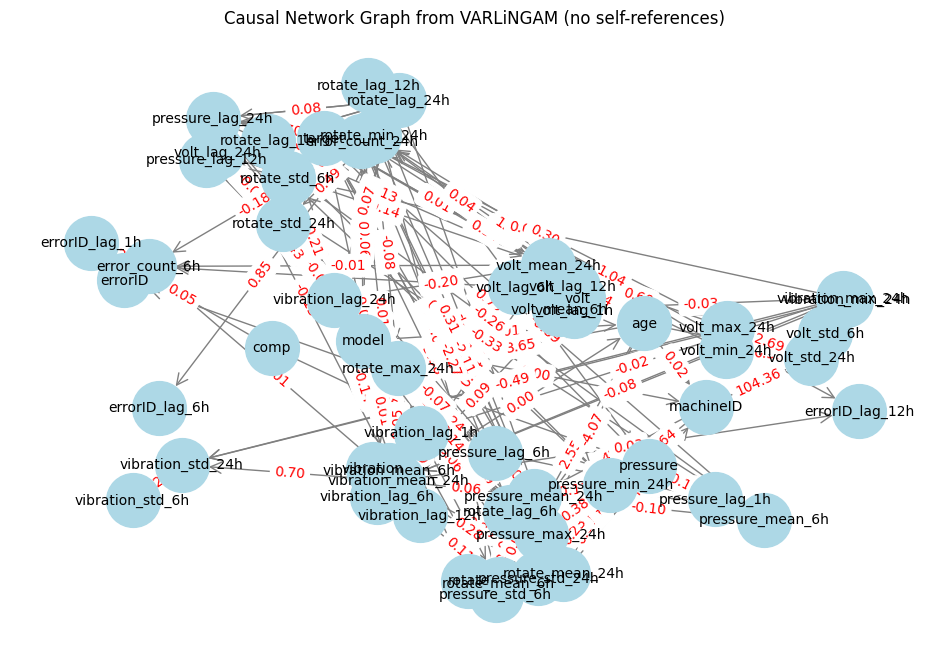

In [18]:
display(fig)

---

<br> <br> 

# Generate top-n rows using SHAP

#### Read ML models

In [19]:
model_dir = "models/"
pkl_files = glob.glob(os.path.join(model_dir, "*.pkl"))

models = {}
for file_path in pkl_files:
    model_name = os.path.splitext(os.path.basename(file_path))[0]
    with open(file_path, "rb") as f:
        models[model_name] = pickle.load(f)

print(f"Loaded {len(models)} models: {list(models.keys())}")

my_models = {
    "catboost_model": 'CatBoost', 
    "lightgbm_model": 'LightGBM', 
    "randomforest_model": 'RandomForest', 
    "xgboost_model": 'XGBoost'
}

# model = models["XGBoost"]
# model = models[my_models["catboost_model"]]
# model = models[my_models["lightgbm_model"]]
# model = models[my_models["randomforest_model"]]
model = models[my_models["xgboost_model"]]
model



Loaded 4 models: ['CatBoost', 'LightGBM', 'RandomForest', 'XGBoost']


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, objective='multi:softprob', ...)

<br> <br> <br>

## Find Uncertain Rows

In [20]:
X_test
# y_test

,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,volt_lag_1h,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
1795,79,0.177043,0.515319,0.168095,0.379322,3,14,0,0,0.577623,...,0.131766,0.090810,0.641680,0.393812,0.097687,0.0,0.0,0.0,0.0,0.0
1796,59,0.545239,0.442839,0.558633,0.310356,3,17,0,0,0.490945,...,0.114023,0.141399,0.691345,0.469230,0.091302,0.0,0.0,0.0,0.0,3.0
1797,64,0.321712,0.445715,0.188939,0.436325,3,20,0,0,0.459217,...,0.094850,0.204042,0.574273,0.432314,0.074643,0.0,0.0,0.0,0.0,2.0
1798,1,0.503970,0.329064,0.201818,0.471551,3,18,0,0,0.379096,...,0.134322,0.103388,0.693047,0.430160,0.162676,0.0,0.0,0.0,0.0,2.0
1799,1,0.503970,0.329064,0.201818,0.471551,3,18,0,0,0.379096,...,0.134322,0.103388,0.693047,0.430160,0.162676,0.0,0.0,0.0,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2239,15,0.813549,0.652503,0.789897,0.700831,3,14,0,0,0.574782,...,0.157192,0.482895,0.960479,0.596342,0.072981,0.0,0.0,0.0,0.0,5.0
2240,64,0.620622,0.515321,0.275955,0.411961,3,20,0,0,0.776013,...,0.099582,0.260616,0.617613,0.414530,0.099916,0.0,0.0,0.0,0.0,1.0
2241,90,0.649523,0.861376,0.429001,0.530115,2,2,0,0,0.619601,...,0.127223,0.113249,0.553388,0.414885,0.098397,0.0,0.0,0.0,0.0,1.0
2242,19,0.312732,0.250477,0.244520,0.182858,3,17,0,0,0.628340,...,0.095823,0.145893,0.527555,0.396740,0.129451,0.0,0.0,0.0,0.0,0.0


In [21]:
def get_uncertain_rows(X_test, y_test, model, uncertainty_threshold=0.6):
    """
    Returns rows from X_test where the model's prediction confidence is below the uncertainty_threshold
    and the true target is not 0. Also prints the predicted class, its probability, and the true target value for each uncertain row.

    Parameters:
        X_test (pd.DataFrame): Test features.
        y_test (array-like): True labels for X_test.
        model: Trained ML model with predict_proba method.
        uncertainty_threshold (float): Maximum probability threshold for uncertainty.

    Returns:
        pd.DataFrame: Uncertain rows from X_test with their true and predicted labels and probabilities.
    """
    probs = model.predict_proba(X_test)
    max_probs = probs.max(axis=1)
    preds = model.classes_[probs.argmax(axis=1)]
    mask = (max_probs < uncertainty_threshold) & (y_test != 0)

    uncertain_rows = X_test[mask].copy()
    uncertain_rows['true_label'] = y_test[mask]
    uncertain_rows['predicted_label'] = preds[mask]
    uncertain_rows['max_probability'] = max_probs[mask]
    uncertain_rows['all_probabilities'] = list(probs[mask])

    # Print predicted class, probability, and true target value for each uncertain row
    for idx, row in uncertain_rows.iterrows():
        print(
            f"Index: {idx}, Predicted class: {row['predicted_label']}, "
            f"Probability: {row['max_probability']:.4f}, True target value: {row['true_label']}"
        )

    return uncertain_rows

# Example usage:
uncertain_rows = get_uncertain_rows(X_test=X_test, y_test=y_test, model=model, uncertainty_threshold=0.8)
display(uncertain_rows)



Index: 1818, Predicted class: 2, Probability: 0.7034, True target value: 2
Index: 1853, Predicted class: 1, Probability: 0.5491, True target value: 4
Index: 1871, Predicted class: 1, Probability: 0.7386, True target value: 1
Index: 1872, Predicted class: 1, Probability: 0.7386, True target value: 1
Index: 1873, Predicted class: 1, Probability: 0.7386, True target value: 1
Index: 1875, Predicted class: 1, Probability: 0.7386, True target value: 1
Index: 2037, Predicted class: 3, Probability: 0.7900, True target value: 2
Index: 2096, Predicted class: 0, Probability: 0.5691, True target value: 2
Index: 2124, Predicted class: 3, Probability: 0.6696, True target value: 4


,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,volt_lag_1h,...,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h,true_label,predicted_label,max_probability,all_probabilities
1818,74,0.534959,0.498984,0.387318,0.306257,4,4,0,0,0.553272,...,0.119209,0.0,0.0,0.0,0.0,3.0,2,2,0.703427,"[0.022976179, 0.27222165, 0.7034268, 0.0008027..."
1853,18,0.681309,0.700936,0.524664,0.506651,3,15,0,0,0.705844,...,0.159925,0.0,0.0,0.0,0.0,5.0,4,1,0.549125,"[0.0015211472, 0.54912466, 0.00016144257, 0.00..."
1871,52,0.623599,0.648561,0.401735,0.433222,3,14,0,0,0.656851,...,0.167984,0.0,0.0,0.0,0.0,5.0,1,1,0.738551,"[0.0050099455, 0.738551, 0.000767373, 0.000930..."
1872,52,0.623599,0.648561,0.401735,0.433222,3,14,0,0,0.656851,...,0.167984,0.0,0.0,0.0,0.0,5.0,1,1,0.738551,"[0.0050099455, 0.738551, 0.000767373, 0.000930..."
1873,52,0.623599,0.648561,0.401735,0.433222,3,14,0,0,0.656851,...,0.167984,0.0,0.0,0.0,0.0,5.0,1,1,0.738551,"[0.0050099455, 0.738551, 0.000767373, 0.000930..."
1875,52,0.623599,0.648561,0.401735,0.433222,3,14,0,0,0.656851,...,0.167984,0.0,0.0,0.0,0.0,5.0,1,1,0.738551,"[0.0050099455, 0.738551, 0.000767373, 0.000930..."
2037,16,0.336190,0.503227,0.659134,0.528144,1,3,0,0,0.485505,...,0.050982,0.0,0.0,0.0,0.0,2.0,2,3,0.790001,"[0.10271929, 0.0020367461, 0.102796495, 0.7900..."
2096,53,0.533654,0.389566,0.447996,0.561029,3,5,0,0,0.370725,...,0.172428,0.0,0.0,0.0,4.0,7.0,2,0,0.569078,"[0.5690783, 0.0018610636, 0.41346818, 0.002577..."
2124,99,0.523501,0.304201,0.554969,0.485445,1,14,0,0,0.520893,...,0.143475,0.0,0.0,0.0,0.0,5.0,4,3,0.669584,"[0.0010072931, 0.00014440929, 0.16061929, 0.66..."


In [22]:
row_number = 1818


random_row = X_test.loc[row_number].to_frame().T
random_row_target_label = uncertain_rows.loc[row_number]["true_label"]
print(f"The true label is: {uncertain_rows.loc[row_number]['true_label']}, and the model predicted {uncertain_rows.loc[row_number]['predicted_label']}")

display(random_row)

# random_row.drop(columns=["comp_lag_12h"], inplace=True)

The true label is: 2, and the model predicted 2


,machineID,volt,rotate,pressure,vibration,model,age,errorID,comp,volt_lag_1h,...,vibration_std_24h,vibration_min_24h,vibration_max_24h,vibration_mean_6h,vibration_std_6h,errorID_lag_1h,errorID_lag_6h,errorID_lag_12h,error_count_6h,error_count_24h
1818,74.0,0.534959,0.498984,0.387318,0.306257,4.0,4.0,0.0,0.0,0.553272,...,0.108715,0.220765,0.611158,0.357061,0.119209,0.0,0.0,0.0,0.0,3.0


In [23]:
# Cell 32: get y_test value for the selected random row
try:
    pos = X_test.index.get_loc(row_number)  # position in X_test (matches y_test ordering)
    y_val = y_test[pos]
    print(f"y_test value for row {row_number}: {y_val}")
except KeyError:
    # Fallbacks if the exact index isn't found
    if 'uncertain_rows' in globals() and row_number in uncertain_rows.index:
        print(f"Fallback (uncertain_rows): true_label = {int(uncertain_rows.loc[row_number, 'true_label'])}")
    elif 'random_row_target_label' in globals():
        print(f"Fallback (random_row_target_label variable): {int(random_row_target_label)}")
    else:
        print(f"Row {row_number} not found in X_test and no fallback available.")

y_test value for row 1818: 2


<br> <br> 

## Generate top-n rows using SHAP

,feature_name,feature_importance
0,rotate_std_6h,0.378114
1,volt_std_6h,0.228983
2,rotate_std_24h,0.223704
3,volt,0.148755
4,rotate_lag_12h,0.091916
5,volt_lag_6h,0.082346
6,volt_min_24h,0.080113
7,model,0.067785
8,rotate_min_24h,0.064795
9,errorID,0.059609


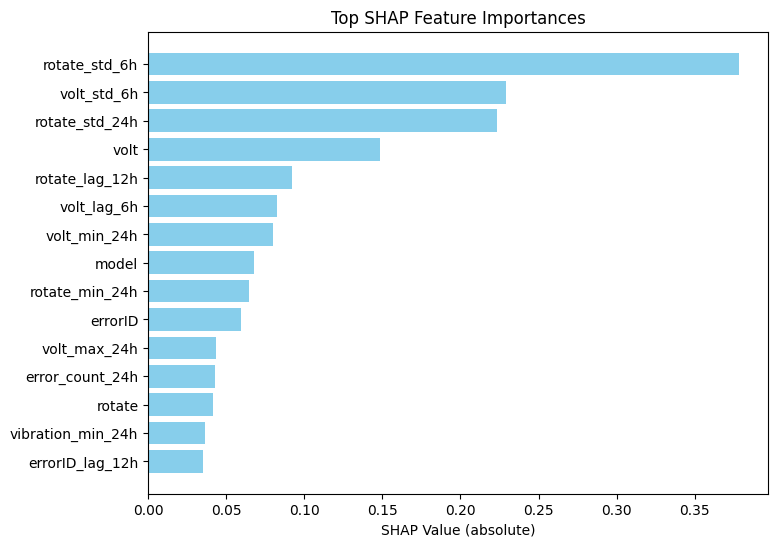

In [24]:
def get_top_n_shap_features(random_row, model, top_n=10):
    feature_names = model.feature_names_in_
    X_row = random_row
    X_row = X_row.apply(pd.to_numeric, errors='coerce')

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_row)

    if isinstance(shap_values, list):
        shap_abs = np.sum([np.abs(sv).reshape(-1) for sv in shap_values], axis=0)
    else:
        shap_abs = np.abs(shap_values).reshape(-1)

    min_len = min(len(feature_names), len(shap_abs))
    df_shap = pd.DataFrame({
        'feature_name': feature_names[:min_len],
        'feature_importance': shap_abs[:min_len]
    }).sort_values('feature_importance', ascending=False).head(top_n).reset_index(drop=True)

    return df_shap


df_shap = get_top_n_shap_features(random_row=random_row, model=model, top_n=15)
display(df_shap)


# Visualize SHAP values from df_shap as a horizontal bar plot
plt.figure(figsize=(8, 6))
plt.barh(df_shap['feature_name'][::-1], df_shap['feature_importance'][::-1], color='skyblue')
plt.xlabel('SHAP Value (absolute)')
plt.title('Top SHAP Feature Importances')
plt.show()

<br> <br>

---

<br> <br> <br>

# Taxonomy  

<br> <br> <br>

## Generate Taxonomy

```python
def generate_taxonomy_with_groq(columns_list, api_key, model="llama3-70b-8192", output_file="groq_taxonomy.json"):
    output_file = f"{output_file}"
    headers = {"Authorization": f"Bearer {api_key}", "Content-Type": "application/json"}

    # API endpoint
    endpoint = "https://api.groq.com/openai/v1/chat/completions"

    # Create the prompt for the taxonomy
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.

    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]
        "Air_temperature_combination": [3, "Air_temperature"]
        
    }}

    **Input Features**:
    {', '.join(columns_list)}
    """

    # Create the request payload
    payload = {
        "model": model,  # Using the model specified as parameter
        "messages": [
            {
                "role": "system",
                "content": "You are a data scientist who organizes features into taxonomies.",
            },
            {"role": "user", "content": prompt},
        ],
        "temperature": 0.2,
    }

    # Make the API call
    response = requests.post(endpoint, headers=headers, json=payload)

    if response.status_code == 200:
        result = response.json()
        content = result["choices"][0]["message"]["content"]

        # Extract JSON from the response
        json_match = re.search(r"{.*}", content, re.DOTALL)
        if json_match:
            taxonomy_json_str = json_match.group(0)
            taxonomy = json.loads(taxonomy_json_str)
        else:
            # If no JSON pattern found, try to parse the whole content
            try:
                taxonomy = json.loads(content)
            except:
                raise ValueError("Failed to parse JSON from API response")

        # Save to file
        with open(output_file, "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        error_message = f"API request failed with status code {response.status_code}"
        try:
            error_details = response.json()
            error_message += f": {error_details}"
        except:
            pass
        raise Exception(error_message)


def generate_taxonomy_with_openai(filename, features, openai_api_key):
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.

    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    3. The hierarchy can be at any levels (e.g. 2,3,4,etc) but should be logical and meaningful.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]

    }}

    **Input Features**:
    {json.dumps(features, indent=2)}
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "system",
                "content": "Respond only with valid JSON, no extra text.",
            },
            {"role": "user", "content": prompt},
        ],
        "response_format": {
            "type": "json_object"
        },  # ✅ Changed from "json" to "json_object"
        "temperature": 0,
    }

    response = requests.post(openai_url, headers=headers, json=data)

    if response.status_code == 200:
        raw_content = response.json()["choices"][0]["message"]["content"].strip()

        # print("🔍 Raw OpenAI Response:\n", raw_content)  # Debugging step

        # Extract only JSON if extra text is present
        json_match = re.search(r"\{.*\}", raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)  # Extract JSON only

        # Try to parse as JSON
        try:
            taxonomy = json.loads(raw_content)
        except json.JSONDecodeError:
            raise RuntimeError(
                f"OpenAI API returned an invalid JSON response:\n{raw_content}"
            )

        # Save taxonomy to a file
        with open(f"{filename}", "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        raise RuntimeError(
            f"Error from OpenAI API: {response.status_code} {response.text}"
        )

def generate_taxonomy_with_openai_edited(filename, features, root_features, openai_api_key):
    prompt = f"""
    **Task**:  
    Create a hierarchical taxonomy for dataset features.

    **Instructions**:
    
    1. **Organize Features Hierarchically**:  
    - Group dataset features based on their semantic meaning and relationships.
    - The taxonomy should show clear parent-child relationships between features.
    - The hierachy MUST NOT include features that are not existed in the dataset's features  
      Dataset's list of feature: {features} 
    -The roots of the hierarchy are {root_features}. These features can not have parents.


    2. **Output Must Be Valid JSON**:
    - Ensure the response is in **JSON format**.
    - No extra text or explanations.

    3. The hierarchy can be at any levels (e.g. 2,3,4,etc) but should be logical and meaningful.

    **Example Format**:
    {{
        "Type": [1, "Root"],
        "Temperature": [1, "Root"],
        "Air_temperature": [2, "Temperature"]

    }}

    **Input Features**:
    {json.dumps(features, indent=2)}
    """

    openai_url = "https://api.openai.com/v1/chat/completions"
    headers = {
        "Authorization": f"Bearer {openai_api_key}",
        "Content-Type": "application/json",
    }
    data = {
        "model": "gpt-4o",
        "messages": [
            {
                "role": "system",
                "content": "Respond only with valid JSON, no extra text.",
            },
            {"role": "user", "content": prompt},
        ],
        "response_format": {
            "type": "json_object"
        },  # ✅ Changed from "json" to "json_object"
        "temperature": 0,
    }

    response = requests.post(openai_url, headers=headers, json=data)

    if response.status_code == 200:
        raw_content = response.json()["choices"][0]["message"]["content"].strip()

        # print("🔍 Raw OpenAI Response:\n", raw_content)  # Debugging step

        # Extract only JSON if extra text is present
        json_match = re.search(r"\{.*\}", raw_content, re.DOTALL)
        if json_match:
            raw_content = json_match.group(0)  # Extract JSON only

        # Try to parse as JSON
        try:
            taxonomy = json.loads(raw_content)
        except json.JSONDecodeError:
            raise RuntimeError(
                f"OpenAI API returned an invalid JSON response:\n{raw_content}"
            )

        # Save taxonomy to a file
        with open(f"{filename}", "w") as f:
            json.dump(taxonomy, f, indent=2)

        return taxonomy
    else:
        raise RuntimeError(
            f"Error from OpenAI API: {response.status_code} {response.text}"
        )
```

<br> <br> <br>

### Generate the taxonomy


```python
llama3_taxonomy = generate_taxonomy_with_groq(columns_list=df.columns, api_key=groq_api_key, model="llama-3.3-70b-versatile", output_file="taxonomy/llama3.json")

gemma2_taxonomy = generate_taxonomy_with_groq(columns_list=df.columns, api_key=groq_api_key, model="gemma2-9b-it", output_file="taxonomy/gemma2.json")

deepseek_taxonomy = generate_taxonomy_with_groq(columns_list=df.columns, api_key=groq_api_key, model="deepseek-r1-distill-llama-70b", output_file="taxonomy/deepseek.json")

gpt4o_taxonomy = generate_taxonomy_with_openai(filename="taxonomy/gpt4o.json", features=df.columns.tolist(), openai_api_key=openai_api_key)

root_features = ["datetime", "volt", "rotate", "pressure", "vibration", "errorID", "comp", "failure"]
gpt4o_edited_taxonomy = generate_taxonomy_with_openai_edited(filename="taxonomy/gpt4o_edited.json", 
                                                             features=df.columns.tolist(), 
                                                             root_features = root_features, 
                                                             openai_api_key=openai_api_key)```

<br> <br> <br>

## Load the Taxonomy 

In [ ]:
with open('taxonomy/deepseek.json', 'r') as file:
    deepseek_taxonomy = json.load(file)


with open('taxonomy/gemma2.json', 'r') as file:
    gemma2_taxonomy = json.load(file)


with open('taxonomy/llama3.json', 'r') as file:
    llama3_taxonomy = json.load(file)


with open('taxonomy/gpt4o.json', 'r') as file:
    gpt4o_taxonomy = json.load(file)


with open('taxonomy/gpt4o_edited.json', 'r') as file:
    gpt4o_edited_taxonomy = json.load(file)    

In [ ]:
def get_taxonomy_paths(taxonomy_json, node_names):
    
    """Returns hierarchical paths for given nodes in a taxonomy."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON if it's a string

    # Reverse lookup: Map each child to its parent
    child_to_parent = {child: parent for child, (_, parent) in taxonomy_json.items()}

    def get_path(node):
        """Recursively constructs the hierarchy path for a node."""
        path = [node]
        while node in child_to_parent and child_to_parent[node] != "Root":
            node = child_to_parent[node]
            path.append(node)
        return " --> ".join(reversed(path))  # Reverse to get correct hierarchy order
    return {node: get_path(node) for node in node_names}



def format_taxonomy(taxonomy_json):
    """Formats a hierarchical taxonomy into a tree-like string."""
    if isinstance(taxonomy_json, str):
        taxonomy_json = json.loads(taxonomy_json)  # Parse JSON string if needed

    # Build tree structure
    tree = defaultdict(list)
    for feature, (_, parent) in taxonomy_json.items():
        tree[parent].append(feature)

    def display_tree(parent="Root", level=0):
        """Recursively formats the tree structure with icons and connectors."""
        if parent not in tree:
            return ""

        result = ""
        for idx, child in enumerate(tree[parent]):
            is_parent = child in tree  # Check if child has further children
            icon = "📂" if is_parent else "📄"  # Folder for parents, file for leaf nodes
            connector = "└── " if idx == len(tree[parent]) - 1 else "├── "  # Tree connectors
            result += "  " * level + connector + f"{icon} {child}\n"
            result += display_tree(child, level + 1)  # Recursive call for children

        return result

    return f"\n📌 **Taxonomy Structure:**\n\n{display_tree('Root')}".strip()



def format_taxonomy_deepseek(taxonomy: Union[str, dict]) -> str:
    """
    Accept either a dict loaded from JSON (key -> [level, category])
    or a filepath to a JSON file. Returns a formatted string and prints it.
    """
    # load if a path was passed
    if isinstance(taxonomy, str):
        with open(taxonomy, "r", encoding="utf-8") as f:
            taxonomy = json.load(f)

    # validate structure
    if not isinstance(taxonomy, dict):
        raise ValueError("taxonomy must be a dict or a path to a JSON file")

    # build mapping: category -> list of (feature, level)
    cat_map = defaultdict(list)
    for feat, meta in taxonomy.items():
        # meta expected like [level, category] but be tolerant
        if isinstance(meta, (list, tuple)) and len(meta) >= 2:
            level, category = meta[0], meta[1]
        elif isinstance(meta, dict):
            level = meta.get("level", None)
            category = meta.get("category", "Uncategorized")
        else:
            level = None
            category = "Uncategorized"
        cat_map[str(category)].append((feat, level))

    # create printable output sorted by category then feature
    lines = []
    for category in sorted(cat_map.keys()):
        lines.append(f"Category: {category}")
        # sort features by level (if numeric) then name
        items = sorted(cat_map[category], key=lambda x: (x[1] if isinstance(x[1], (int,float)) else 999, x[0]))
        for feat, level in items:
            lines.append(f"  - {feat} (level={level})")
        lines.append("")  # blank line

    out = "\n".join(lines)
    print(out)   # ensure output appears in notebooks/console
    return out


In [ ]:
tx_index = 2
taxonomy_model = [gpt4o_taxonomy, llama3_taxonomy, gemma2_taxonomy, gpt4o_edited_taxonomy]

print(format_taxonomy(taxonomy_model[tx_index]))

print(f"\n\n\n {'-'*100} \n\n\n")

# For deepSeek run the following method
print(format_taxonomy_deepseek(deepseek_taxonomy))

In [ ]:
shap_features = {
    'feature': df_shap["feature_name"].to_list()
}
features_to_find = shap_features["feature"]

taxonomy_model = [gpt4o_taxonomy, llama3_taxonomy, gemma2_taxonomy, deepseek_taxonomy, gpt4o_edited_taxonomy, ]
index = 4

match index:
    case 0:
        print("GPT-4o")
    case 1:
        print("Llama 3.3")
    case 2:
        print("Gemma2")
    case 3:
        print("DeepSeek")
    case 4:
        print("GPT-4o Edited")
    case _:
        print("Unknown model")

try:
    # Get paths for all selected features
    feature_paths = get_taxonomy_paths(taxonomy_model[index], features_to_find)

    # Print the results in a formatted way, removing "Sensor_Reading --> " from the start
    print("\n=== Taxonomy Paths ===\n")
    for feature, path in feature_paths.items():
        if path.startswith("Sensor_Readings --> "):
            path = path[len("Sensor_Readings --> "):]
        print(f"{path}")
except IndexError as e:
    print("Taxonomy model index is out of reach")

<br> <br>

#### See the hierarchy

In [ ]:
# Test the function with the openai_taxonomy data

shap_features = {
    'feature': df_shap["feature_name"].to_list()
}
features_to_find = shap_features["feature"]

taxonomy_model = [gpt4o_taxonomy, llama3_taxonomy, gemma2_taxonomy, deepseek_taxonomy, gpt4o_edited_taxonomy, ]
index = 4

match index:
    case 0:
        print("GPT-4o")
    case 1:
        print("Llama 3.3")
    case 2:
        print("Gemma2")
    case 3:
        print("DeepSeek")
    case 4:
        print("GPT-4o Edited")
    case _:
        print("Unknown model")

try:
    # Get paths for all selected features
    feature_paths = get_taxonomy_paths(taxonomy_model[index], features_to_find)

    # Print the results in a formatted way, removing "Sensor_Reading --> " from the start
    print("\n=== Taxonomy Paths ===\n")
    for feature, path in feature_paths.items():
        if path.startswith("Sensor_Readings --> "):
            path = path[len("Sensor_Readings --> "):]
        print(f"{path}")
except IndexError as e:
    print("Taxonomy model index is out of reach")

<br> <br>

---

<br> <br> <br>

## Visualize The subgraph - Advanced Visualization - Target included


In [43]:
def create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph.html", width="100%", height="1000px"):
    """
    Creates an interactive HTML visualization of the causal graph containing top SHAP features.
    
    This version includes the top_n_sub_nodes filtering logic and creates an interactive visualization
    using pyvis instead of matplotlib.

    Args:
        df_shap (pd.DataFrame): DataFrame with a 'feature_name' column identifying the core features.
        structured_adjacency (list): List of dicts with 'source_feature', 'target_feature', 
                                     and 'effect_strength' keys.
        top_n_sub_nodes (int, optional): The number of top related nodes to include in the graph,
                                         ranked by absolute effect_strength. If None, all directly
                                         connected nodes are included. Defaults to None.
        filename (str): The name of the output HTML file. Defaults to "interactive_causal_graph.html".
        width (str): Width of the visualization. Defaults to "100%".
        height (str): Height of the visualization. Defaults to "1000px".
    
    Returns:
        str: JSON string of the subgraph (same as original function).
    """
    import networkx as nx
    import json
    import pandas as pd
    from pyvis.network import Network

    top_features = set(df_shap["feature_name"])
    target_variable = 'target'  # Define the target variable name
    
    # Store original effect strengths for JSON output
    edge_strengths = {}
    
    # If top_n_sub_nodes is specified, filter to the most influential relationships
    if top_n_sub_nodes is not None and isinstance(top_n_sub_nodes, int) and top_n_sub_nodes >= 0:
        # 1. Find all edges connecting top_features to other nodes (sub-nodes), excluding target
        relevant_edges = []
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            strength = abs(edge.get("effect_strength", 0))  # Use absolute strength for ranking
            
            # Find relationships where one node is in top_features and the other is not (excluding target variable)
            if source in top_features and target not in top_features and target != target_variable:
                relevant_edges.append({
                    'top_feature': source,
                    'sub_node': target,
                    'strength': strength,
                    'original_edge': edge
                })
            elif target in top_features and source not in top_features and source != target_variable:
                relevant_edges.append({
                    'top_feature': target,
                    'sub_node': source,
                    'strength': strength,
                    'original_edge': edge
                })
        
        # 2. Sort all relationships by effect strength and select top N
        sorted_relationships = sorted(relevant_edges, key=lambda x: x['strength'], reverse=True)
        top_relationships = sorted_relationships[:top_n_sub_nodes]
        
        # 3. Get the set of sub-nodes from top N relationships
        top_sub_nodes_set = {rel['sub_node'] for rel in top_relationships}
        
        print(f"Selected top {len(top_relationships)} relationships with sub-nodes: {top_sub_nodes_set}")
        for i, rel in enumerate(top_relationships, 1):
            print(f"  {i}. {rel['top_feature']} ↔ {rel['sub_node']} (strength: {rel['strength']:.4f})")
        
        # 4. The final set of nodes includes top features, selected sub-nodes, AND target variable
        allowed_nodes = top_features.union(top_sub_nodes_set).union({target_variable})
        
        # 5. Filter edges where both source and target are in our allowed set
        sub_edges = []
        edge_labels = {}
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            if source in allowed_nodes and target in allowed_nodes:
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
    else:
        # Original logic: include all nodes directly connected to any top_feature, PLUS target variable
        sub_edges = []
        edge_labels = {}
        allowed_nodes = set()
        
        for edge in structured_adjacency:
            source, target = edge["source_feature"], edge["target_feature"]
            # Include edges connected to top_features OR target variable
            if (source in top_features) or (target in top_features) or (source == target_variable) or (target == target_variable):
                sub_edges.append((source, target))
                effect_strength = edge.get("effect_strength", 0)
                edge_labels[(source, target)] = f'{effect_strength:.3f}'
                edge_strengths[(source, target)] = effect_strength  # Store original value
                allowed_nodes.add(source)
                allowed_nodes.add(target)

    # Create NetworkX graph
    G = nx.DiGraph()
    G.add_edges_from(sub_edges)
    
    # Add edge labels as attributes to the graph
    for (u, v), label in edge_labels.items():
        if G.has_edge(u, v):
            G.edges[u, v]['label'] = label

    # If the graph is empty, return an empty JSON and skip visualization
    if not G.nodes():
        print("Warning: The resulting graph is empty. No relationships found based on the criteria.")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Create interactive visualization using pyvis
    print(f"Creating interactive visualization with {len(G.nodes())} nodes and {len(G.edges())} edges...")
    
    net = Network(height=height, width=width, notebook=False, directed=True, cdn_resources='in_line')

    # Set physics options for better layout and interactivity
    net.set_options("""
    var options = {
      "physics": {
        "enabled": true,
        "repulsion": { 
          "centralGravity": 0.2, 
          "springLength": 200, 
          "nodeDistance": 300,
          "damping": 0.1
        },
        "minVelocity": 0.75,
        "solver": "repulsion",
        "timestep": 0.22,
        "stabilization": {"iterations": 150}
      },
      "edges": {
        "arrows": {
          "to": {"enabled": true, "scaleFactor": 1.5}
        },
        "smooth": {
          "enabled": true,
          "type": "continuous"
        }
      },
      "interaction": {
        "dragNodes": true,
        "dragView": true,
        "zoomView": true,
        "selectConnectedEdges": true,
        "hover": true,
        "multiselect": true,
        "keyboard": {
          "enabled": true
        }
      },
      "manipulation": {
        "enabled": false
      }
    }
    """)

    # Add nodes to the pyvis network with enhanced interactivity
    for node in G.nodes():
        is_top = node in top_features
        is_target = node == target_variable  
        
        # Determine node styling based on type
        if is_target:
            color = 'red'
            node_type = '🎯 TARGET VARIABLE'
            size = 35  # Larger size for target
        elif is_top:
            color = 'orange'
            node_type = '⭐ Top SHAP Feature'
            size = 25
        else:
            color = 'skyblue'
            node_type = '🔗 Related Feature'
            size = 20
            
        net.add_node(
            node, 
            label=node, 
            color=color,
            shape='box', 
            shadow=True, 
            font={'size': 18, 'color': 'black', 'strokeWidth': 2, 'strokeColor': 'white'},
            size=size,
            borderWidth=3 if is_target else 2,
            borderWidthSelected=5 if is_target else 4,
            title=f"{node_type}: {node}<br/>Click and drag to move!"  # Enhanced tooltip
        )

    # Add edges to the pyvis network with enhanced styling
    for u, v in G.edges():
        label = G.edges[u, v].get('label', '')
        is_highlight = (u in top_features and v in top_features)
        is_target_edge = (u == target_variable or v == target_variable)
        
        # Special styling for edges connected to target
        if is_target_edge:
            edge_color = 'darkred'
            edge_width = 5
            edge_title = f"🎯 TARGET CONNECTION - Effect strength: {label}<br/>From: {u} → To: {v}"
        elif is_highlight:
            edge_color = 'red'
            edge_width = 4
            edge_title = f"📊 SHAP-SHAP Connection - Effect strength: {label}<br/>From: {u} → To: {v}"
        else:
            edge_color = 'gray'
            edge_width = 2
            edge_title = f"📊 Effect strength: {label}<br/>From: {u} → To: {v}"
            
        net.add_edge(
            u, v, 
            label=label, 
            color=edge_color,
            width=edge_width,
            title=edge_title,  # Enhanced tooltip
            font={'size': 12, 'color': 'blue', 'strokeWidth': 1, 'strokeColor': 'white'}
        )

    # Generate and save HTML content with proper encoding
    html_content = net.generate_html()
    try:
        with open(filename, "w", encoding="utf-8") as f:
            f.write(html_content)
        print(f"[SUCCESS] Interactive graph saved to '{filename}'. Open this file in your browser.")
    except Exception as e:
        print(f"[ERROR] Could not save the HTML file. Reason: {e}")
        return json.dumps({"nodes": [], "edges": []}, indent=2)

    # Generate JSON output (same as original function, but include target info)
    subgraph_json = {
        "nodes": [
            {
                "id": node, 
                "highlight": node in top_features,
                "is_target": node == target_variable,
                "node_type": "target" if node == target_variable else ("shap_feature" if node in top_features else "related_feature")
            }
            for node in G.nodes()
        ],
        "edges": [
            {
                "source": u,
                "target": v,
                "highlight": (u in top_features and v in top_features),
                "is_target_connection": (u == target_variable or v == target_variable),
                "effect_strength": edge_strengths.get((u, v), 0.0)  # Use original numeric value
            }
            for u, v in G.edges()
        ]
    }
    
    return json.dumps(subgraph_json, indent=2)

In [27]:
# Example usage with custom size:
# For a larger plot:
# result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=7, filename="large_graph.html", width="1400px", height="1200px")
# 
# For full screen:
result = create_interactive_visualization_with_target(df_shap, structured_adjacency, top_n_sub_nodes=None, filename="interactive_causal_graph_with_target-22-08-2025.html", width="100vw" , height="100vh")

Creating interactive visualization with 43 nodes and 69 edges...
[SUCCESS] Interactive graph saved to 'interactive_causal_graph_with_target-22-08-2025.html'. Open this file in your browser.


In [44]:
df_shap

,feature_name,feature_importance
0,rotate_std_6h,0.367259
1,volt_std_6h,0.229310
2,error_count_24h,0.186549
3,rotate_std_24h,0.169954
4,model,0.154094
5,rotate_lag_12h,0.134349
6,vibration_min_24h,0.133447
7,volt,0.108535
8,volt_lag_1h,0.097405
9,volt_std_24h,0.088933


<br> <br> <br>

---


<br> <br> <br>

---

## Perturb Only one features at a time 
#### Integration with Causal graph 

## Note

the current method:

✅ Single-feature focus - Changes only one feature at a time<br>
✅ Fast and systematic - Tests specific perturbation levels<br>
✅ Causal guidance integration - Uses VARLiNGAM adjacency matrix<br>
✅ Transparent control - You control exactly which feature changes and by how much<br>


dice_ml approach:

❌ Multi-feature changes - Often changes multiple features simultaneously<br>
❌ Less control - Internal optimization decides perturbation levels<br>
❌ No direct causal integration - Doesn't use your structured_adjacency<br>


<br> <br> <br>

---

In [57]:
import numpy as np
import pandas as pd
import random
from typing import List, Dict, Tuple, Optional

def extract_causal_guidance(structured_adjacency: List[Dict], target_features: List[str]) -> Dict:
    """
    Extract causal guidance for target features from structured adjacency matrix.
    
    Args:
        structured_adjacency: List of dicts with 'source_feature', 'target_feature', 'effect_strength'
        target_features: List of feature names we want guidance for
        
    Returns:
        Dict with causal information for each feature
    """
    causal_info = {}
    
    for edge in structured_adjacency:
        source = edge['source_feature']
        target = edge['target_feature']
        strength = edge['effect_strength']
        
        # Look for direct causal effects TO the target variable
        if target == 'target' and source in target_features:
            causal_info[source] = {
                'effect_strength': abs(strength),
                'effect_direction': 1 if strength > 0 else -1,
                'relationship_type': 'direct_to_target',
                'preferred_direction': 'increase' if strength > 0 else 'decrease'
            }
        
        # Look for causal relationships between features (indirect effects)
        elif source in target_features and target in target_features:
            if source not in causal_info:
                causal_info[source] = {
                    'effect_strength': abs(strength),
                    'effect_direction': 1 if strength > 0 else -1,
                    'relationship_type': 'inter_feature',
                    'preferred_direction': 'increase' if strength > 0 else 'decrease',
                    'affects_feature': target
                }
    
    return causal_info


def prioritize_features_causally(user_features: List[str], structured_adjacency: List[Dict]) -> List[Dict]:
    """
    Prioritize features based on their causal importance to the target.
    
    Args:
        user_features: List of SHAP important features
        structured_adjacency: Causal graph edges
        
    Returns:
        List of feature dicts sorted by causal priority
    """
    feature_priority = []
    
    # Create mapping of direct causal effects to target
    direct_effects = {}
    for edge in structured_adjacency:
        if edge['target_feature'] == 'target' and edge['source_feature'] in user_features:
            direct_effects[edge['source_feature']] = abs(edge['effect_strength'])
    
    # Assign priorities
    for i, feature in enumerate(user_features):
        if feature in direct_effects:
            # Direct causal effect - higher priority
            causal_strength = direct_effects[feature]
            priority_score = causal_strength * 10  # Boost direct effects
        else:
            # No direct causal effect found
            priority_score = 0
        
        feature_priority.append({
            'feature': feature,
            'causal_priority': priority_score,
            'shap_rank': i + 1,
            'has_causal_effect': feature in direct_effects
        })
    
    # Sort by causal priority (descending), then by SHAP rank (ascending)
    feature_priority.sort(key=lambda x: (-x['causal_priority'], x['shap_rank']))
    
    return feature_priority


def get_causal_perturbation_strategy(causal_guidance: Dict, perturbation_levels: List[float], 
                                   original_prediction: int) -> Tuple[List[int], List[float]]:
    """
    Determine optimal perturbation strategy based on causal guidance.
    
    Args:
        causal_guidance: Causal info for the feature
        perturbation_levels: Available perturbation levels
        original_prediction: Current model prediction
        
    Returns:
        Tuple of (directions, levels) to try
    """
    effect_direction = causal_guidance.get('effect_direction', 1)
    effect_strength = causal_guidance.get('effect_strength', 0)
    
    # Determine target prediction (what we want to achieve)
    target_prediction = 1 - original_prediction
    
    # Determine optimal direction based on causal effect
    if target_prediction == 1 and effect_direction > 0:
        # Want prediction=1, feature has positive effect → increase feature
        directions = [1, -1]  # Try increase first
    elif target_prediction == 1 and effect_direction < 0:
        # Want prediction=1, feature has negative effect → decrease feature
        directions = [-1, 1]  # Try decrease first
    elif target_prediction == 0 and effect_direction > 0:
        # Want prediction=0, feature has positive effect → decrease feature
        directions = [-1, 1]  # Try decrease first
    else:
        # Want prediction=0, feature has negative effect → increase feature
        directions = [1, -1]  # Try increase first
    
    # Adjust perturbation levels based on effect strength
    if effect_strength > 0.8:  # Very strong causal effect
        levels = [l for l in perturbation_levels if l <= 0.5]  # Small perturbations
    elif effect_strength > 0.5:  # Strong causal effect
        levels = [l for l in perturbation_levels if l <= 1.0]  # Medium perturbations
    elif effect_strength > 0.2:  # Moderate causal effect
        levels = perturbation_levels  # All levels
    else:  # Weak causal effect
        levels = [l for l in perturbation_levels if l >= 0.1]  # Larger perturbations
    
    return directions, levels


def check_causal_alignment(causal_guidance: Dict, perturbation_direction: int, 
                         original_prediction: int) -> str:
    """
    Check if the successful perturbation aligns with causal expectations.
    
    Args:
        causal_guidance: Causal info for the feature
        perturbation_direction: Direction of perturbation (+1 or -1)
        original_prediction: Original model prediction
        
    Returns:
        Alignment status: 'aligned', 'contrary', or 'no_causal_info'
    """
    if not causal_guidance:
        return "no_causal_info"
    
    effect_direction = causal_guidance.get('effect_direction', 1)
    target_prediction = 1 - original_prediction
    
    # Calculate expected perturbation direction
    if target_prediction == 1 and effect_direction > 0:
        expected_direction = 1  # Should increase feature
    elif target_prediction == 1 and effect_direction < 0:
        expected_direction = -1  # Should decrease feature
    elif target_prediction == 0 and effect_direction > 0:
        expected_direction = -1  # Should decrease feature
    else:
        expected_direction = 1  # Should increase feature
    
    if perturbation_direction == expected_direction:
        return "aligned"
    else:
        return "contrary"


def generate_single_feature_counterfactuals(model, random_row: pd.DataFrame, user_features: List[str],
                                          structured_adjacency: Optional[List[Dict]] = None,
                                          perturbation_levels: Optional[List[float]] = None,
                                          use_causal_guidance: bool = True,
                                          random_seed: int = 42) -> pd.DataFrame:
    """
    Generate counterfactuals by perturbing ONE feature at a time with causal guidance.
    
    Args:
        model: Trained ML model
        random_row: Single row DataFrame to generate counterfactuals for
        user_features: List of SHAP important features
        structured_adjacency: List of causal relationships (optional)
        perturbation_levels: List of perturbation levels as fractions
        use_causal_guidance: Whether to use causal information
        random_seed: Random seed for reproducibility
        
    Returns:
        DataFrame with successful counterfactuals
    """
    print("🎯 Generating Single-Feature Counterfactuals with Causal Guidance")
    print("=" * 70)
    
    # Set random seeds
    np.random.seed(random_seed)
    random.seed(random_seed)
    
    # Default perturbation levels
    if perturbation_levels is None:
        perturbation_levels = [0.05, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0, 1.5, 2.0]
    
    # Validate features
    available_features = set(random_row.columns)
    valid_user_features = [f for f in user_features if f in available_features]
    invalid_features = [f for f in user_features if f not in available_features]
    
    if invalid_features:
        print(f"⚠️ Warning: Features not available: {invalid_features}")
    
    if not valid_user_features:
        print("❌ Error: No valid features provided.")
        return pd.DataFrame()
    
    print(f"✅ Testing {len(valid_user_features)} features")
    
    # Extract causal guidance
    causal_info = {}
    if structured_adjacency and use_causal_guidance:
        print("🔗 Extracting causal guidance...")
        causal_info = extract_causal_guidance(structured_adjacency, valid_user_features)
        
        if causal_info:
            print(f"✅ Found causal guidance for {len(causal_info)} features")
            for feature, info in causal_info.items():
                print(f"   {feature}: effect={info['effect_strength']:.3f}, direction={info['preferred_direction']}")
        else:
            print("⚠️ No direct causal relationships to target found")
    
    # Get baseline prediction
    original_prediction = model.predict(random_row)[0]
    original_proba = model.predict_proba(random_row)[0]
    original_values = random_row.iloc[0].copy()
    
    print(f"\n📊 Original prediction: {original_prediction}")
    print(f"📊 Original probability: {original_proba}")
    print(f"🎯 Target prediction: {1 - original_prediction}")
    
    # Prioritize features
    if causal_info and use_causal_guidance:
        feature_priority = prioritize_features_causally(valid_user_features, structured_adjacency)
        print(f"\n🔗 Causal-guided feature order: {[f['feature'] for f in feature_priority[:5]]}...")
    else:
        feature_priority = [{'feature': f, 'causal_priority': 0, 'shap_rank': i+1} 
                          for i, f in enumerate(valid_user_features)]
        print(f"\n📊 SHAP-guided feature order: {[f['feature'] for f in feature_priority[:5]]}...")
    
    successful_counterfactuals = []
    
    # Test each feature
    for feature_info in feature_priority:
        feature = feature_info['feature']
        shap_rank = feature_info['shap_rank']
        
        print(f"\n🔍 Testing feature #{shap_rank}: {feature}")
        
        original_val = original_values[feature]
        print(f"   Original value: {original_val:.4f}")
        
        # Get causal guidance for this feature
        causal_guidance = causal_info.get(feature, {})
        
        # Determine perturbation strategy
        if causal_guidance and use_causal_guidance:
            directions, levels = get_causal_perturbation_strategy(
                causal_guidance, perturbation_levels, original_prediction
            )
            strategy_type = "causal-guided"
            print(f"   🔗 Causal strategy: {causal_guidance.get('preferred_direction', 'unknown')} first")
        else:
            directions = [1, -1]  # Both directions
            levels = perturbation_levels
            strategy_type = "standard"
            print(f"   📊 Standard strategy: both directions")
        
        # Try perturbations
        found_counterfactual = False
        
        for direction in directions:
            if found_counterfactual:
                break
                
            direction_name = "increase" if direction == 1 else "decrease"
            
            for level in levels:
                if found_counterfactual:
                    break
                
                # Calculate new value
                change = original_val * level * direction
                new_val = original_val + change
                
                # Create perturbed row
                perturbed_row = random_row.copy()
                perturbed_row.loc[perturbed_row.index[0], feature] = new_val
                
                try:
                    # Check prediction
                    new_prediction = model.predict(perturbed_row)[0]
                    new_proba = model.predict_proba(perturbed_row)[0]
                    
                    if new_prediction != original_prediction:
                        # Success! Create counterfactual record
                        percent_change = (change / original_val * 100) if original_val != 0 else float('inf')
                        
                        counterfactual = {
                            'counterfactual_id': len(successful_counterfactuals),
                            'feature_changed': feature,
                            'shap_rank': shap_rank,
                            'causal_priority': feature_info.get('causal_priority', 0),
                            'strategy_used': strategy_type,
                            'direction': direction_name,
                            'perturbation_level': level,
                            'original_value': original_val,
                            'new_value': new_val,
                            'absolute_change': change,
                            'percent_change': percent_change,
                            'original_prediction': original_prediction,
                            'new_prediction': new_prediction,
                            'original_prob_0': original_proba[0] if len(original_proba) > 1 else 1 - original_proba[0],
                            'original_prob_1': original_proba[1] if len(original_proba) > 1 else original_proba[0],
                            'new_prob_0': new_proba[0] if len(new_proba) > 1 else 1 - new_proba[0],
                            'new_prob_1': new_proba[1] if len(new_proba) > 1 else new_proba[0],
                            'probability_change': (new_proba[1] - original_proba[1]) if len(new_proba) > 1 else (new_proba[0] - original_proba[0]),
                            'causal_effect_strength': causal_guidance.get('effect_strength', None),
                            'causal_alignment': check_causal_alignment(causal_guidance, direction, original_prediction) if causal_guidance else None
                        }
                        
                        successful_counterfactuals.append(counterfactual)
                        found_counterfactual = True
                        
                        # Print success
                        print(f"   ✅ SUCCESS! {direction_name} by {level*100:.1f}% → prediction flip")
                        print(f"      Value: {original_val:.4f} → {new_val:.4f} ({percent_change:+.1f}%)")
                        print(f"      Prediction: {original_prediction} → {new_prediction}")
                        print(f"      Probability: {original_proba[1] if len(original_proba) > 1 else original_proba[0]:.3f} → {new_proba[1] if len(new_proba) > 1 else new_proba[0]:.3f}")
                        
                        if causal_guidance:
                            alignment = counterfactual['causal_alignment']
                            print(f"      Causal alignment: {alignment}")
                        
                        break
                        
                except Exception:
                    continue
        
        if not found_counterfactual:
            print(f"   ❌ No prediction flip found for {feature}")
    
    # Create results DataFrame
    if successful_counterfactuals:
        results_df = pd.DataFrame(successful_counterfactuals)
        
        print(f"\n🎉 SUMMARY: Found {len(results_df)} successful counterfactuals!")
        print("=" * 70)
        
        # Analyze causal vs standard strategies
        if use_causal_guidance and causal_info:
            causal_guided = results_df[results_df['strategy_used'] == 'causal-guided']
            standard = results_df[results_df['strategy_used'] == 'standard']
            
            print(f"🔗 Causal-guided successes: {len(causal_guided)}")
            print(f"📊 Standard approach successes: {len(standard)}")
            
            if len(causal_guided) > 0:
                avg_causal_perturbation = causal_guided['perturbation_level'].mean()
                print(f"   Avg perturbation (causal): {avg_causal_perturbation:.3f}")
                
                aligned = causal_guided[causal_guided['causal_alignment'] == 'aligned']
                print(f"   Causally aligned: {len(aligned)}/{len(causal_guided)}")
            
            if len(standard) > 0:
                avg_standard_perturbation = standard['perturbation_level'].mean()
                print(f"   Avg perturbation (standard): {avg_standard_perturbation:.3f}")
        
        # Show detailed results
        print(f"\n📋 DETAILED RESULTS:")
        for _, row in results_df.iterrows():
            feature = row['feature_changed']
            direction = row['direction']
            level = row['perturbation_level']
            rank = row['shap_rank']
            strategy = row['strategy_used']
            
            print(f"✅ #{rank}: {feature} ({strategy})")
            print(f"   Method: {direction} by {level*100:.1f}%")
            print(f"   Change: {row['original_value']:.4f} → {row['new_value']:.4f} ({row['percent_change']:+.1f}%)")
            print(f"   Prediction: {row['original_prediction']} → {row['new_prediction']}")
            
            if row['causal_alignment']:
                print(f"   Causal: {row['causal_alignment']} (strength: {row['causal_effect_strength']:.3f})")
            print()
        
        return results_df
    
    else:
        print(f"\n❌ No counterfactuals found.")
        print("   Suggestions:")
        print("   - Increase perturbation levels: [0.1, 0.5, 1.0, 2.0, 5.0]")
        print("   - Try different features")
        print("   - Check if model is too stable")
        return pd.DataFrame()


def analyze_counterfactual_effectiveness(results_df: pd.DataFrame) -> pd.DataFrame:
    """
    Analyze the effectiveness of different features for counterfactual generation.
    
    Args:
        results_df: Results from generate_single_feature_counterfactuals
        
    Returns:
        Analysis summary DataFrame
    """
    if results_df.empty:
        return pd.DataFrame()
    
    print("📊 COUNTERFACTUAL EFFECTIVENESS ANALYSIS")
    print("=" * 50)
    
    analysis_data = []
    
    for _, row in results_df.iterrows():
        analysis_data.append({
            'feature': row['feature_changed'],
            'shap_rank': row['shap_rank'],
            'strategy_used': row['strategy_used'],
            'perturbation_needed': row['perturbation_level'],
            'percent_change_needed': abs(row['percent_change']),
            'direction_needed': row['direction'],
            'causal_alignment': row.get('causal_alignment', 'unknown'),
            'causal_strength': row.get('causal_effect_strength', 0),
            'probability_change_magnitude': abs(row['probability_change'])
        })
    
    analysis_df = pd.DataFrame(analysis_data)
    
    # Sort by easiest to flip (smallest perturbation needed)
    analysis_df = analysis_df.sort_values('perturbation_needed')
    
    print("🏆 Features ranked by EASE OF FLIPPING (smallest perturbation first):")
    for i, (_, row) in enumerate(analysis_df.iterrows(), 1):
        feature = row['feature']
        rank = row['shap_rank']
        strategy = row['strategy_used']
        level = row['perturbation_needed']
        direction = row['direction_needed']
        alignment = row['causal_alignment']
        
        print(f"{i}. {feature} (SHAP rank #{rank}, {strategy})")
        print(f"   Needs {level*100:.1f}% {direction}")
        print(f"   Causal alignment: {alignment}")
        print(f"   Probability change: {row['probability_change_magnitude']:.3f}")
        print()
    
    return analysis_df


# # Example usage:
# if __name__ == "__main__":
#     # Your usage would be:
#     results_df = generate_single_feature_counterfactuals(
#         model=model,
#         random_row=random_row,
#         user_features=df_shap["feature_name"].to_list(),
#         structured_adjacency=structured_adjacency,
#         use_causal_guidance=True,
#         perturbation_levels=[0.05, 0.1, 0.2, 0.3, 0.5, 1.0, 2.0],
#         random_seed=42
#     )
    
#     if not results_df.empty:
#         analysis_df = analyze_counterfactual_effectiveness(results_df)
#         print("\n📊 Final Analysis:")
#         display(analysis_df)



**Key improvements with your `structured_adjacency` structure:**

1. **Proper parsing**: Correctly extracts `source_feature`, `target_feature`, and `effect_strength`
2. **Direct target effects**: Prioritizes features that directly affect the `target` variable
3. **Smart perturbation**: Uses causal effect strength to determine perturbation levels
4. **Causal alignment**: Validates if successful perturbations align with causal expectations
5. **Comprehensive analysis**: Provides detailed effectiveness analysis

**Usage:**


In [53]:
results_df = generate_single_feature_counterfactuals(
    model=model,
    random_row=random_row,
    user_features=df_shap["feature_name"].to_list(),
    structured_adjacency=structured_adjacency,  # Your causal graph
    use_causal_guidance=True,
    random_seed=42
)

results_df

🎯 Generating Single-Feature Counterfactuals with Causal Guidance
✅ Testing 15 features
🔗 Extracting causal guidance...
✅ Found causal guidance for 8 features
   model: effect=0.017, direction=decrease
   age: effect=0.339, direction=increase
   volt_std_24h: effect=0.261, direction=increase
   volt_max_24h: effect=2.687, direction=increase
   rotate_std_24h: effect=0.246, direction=increase
   rotate_min_24h: effect=2.581, direction=decrease
   error_count_24h: effect=0.292, direction=decrease
   rotate_std_6h: effect=0.021, direction=increase

📊 Original prediction: 1
📊 Original probability: [1.5211472e-03 5.4912466e-01 1.6144257e-04 2.3666899e-04 4.4895604e-01]
🎯 Target prediction: 0

🔗 Causal-guided feature order: ['age', 'error_count_24h', 'rotate_std_6h', 'volt_std_6h', 'model']...

🔍 Testing feature #15: age
   Original value: 15.0000
   🔗 Causal strategy: increase first
   ❌ No prediction flip found for age

🔍 Testing feature #7: error_count_24h
   Original value: 5.0000
   🔗 Ca

,counterfactual_id,feature_changed,shap_rank,causal_priority,strategy_used,direction,perturbation_level,original_value,new_value,absolute_change,percent_change,original_prediction,new_prediction,original_prob_0,original_prob_1,new_prob_0,new_prob_1,probability_change,causal_effect_strength,causal_alignment
0,0,error_count_24h,7,2.920642,causal-guided,decrease,1.0,5.000000,0.000000,-5.000000,-100.0,1,0,0.001521,0.549125,0.998013,0.001528,-0.547597,0.292064,contrary
1,1,volt_std_6h,2,0.000000,standard,decrease,0.2,0.104515,0.083612,-0.020903,-20.0,1,4,0.001521,0.549125,0.003011,0.107469,-0.441656,NaN,None
2,2,volt_lag_1h,5,0.000000,standard,decrease,0.5,0.705844,0.352922,-0.352922,-50.0,1,4,0.001521,0.549125,0.001376,0.474935,-0.074190,NaN,None
3,3,volt,9,0.000000,standard,decrease,0.2,0.681309,0.545047,-0.136262,-20.0,1,4,0.001521,0.549125,0.001041,0.443875,-0.105250,NaN,None
4,4,volt_max_24h,12,0.000000,causal-guided,decrease,0.3,1.000000,0.700000,-0.300000,-30.0,1,4,0.001521,0.549125,0.001639,0.413693,-0.135431,2.686833,aligned




This will leverage your causal structure to make counterfactual generation more intelligent and interpretable!

In [ ]:
structured_adjacency

<br> <br>

## Helper explanation, step by step, 


---

# 🔹 1. Setup

**Explanation**:
The function initializes seeds, validates features, and sets default perturbation levels. This ensures reproducibility and avoids invalid features.

**Code**:

```python
np.random.seed(random_seed)
random.seed(random_seed)

# Default perturbation levels if not provided
if perturbation_levels is None:
    perturbation_levels = [0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0, 1.5, 2.0]

# Validate user features
available_features = set(random_row.columns)
valid_user_features = [f for f in user_features if f in available_features]
invalid_features = [f for f in user_features if f not in available_features]
```

---

# 🔹 2. Establish Baseline

**Explanation**:
Before perturbing anything, the model’s original prediction and probability are recorded. These act as the reference for counterfactual comparison.

**Code**:

```python
# Get original prediction
original_prediction = model.predict(random_row)[0]
original_proba = model.predict_proba(random_row)[0]
original_values = random_row.iloc[0].copy()

print(f"📊 Original prediction: {original_prediction}")
print(f"📊 Original probability: {original_proba}")
print(f"🎯 Looking for prediction flip to: {1 - original_prediction}")
```

---

# 🔹 3. Extract Causal Guidance from `structured_adjacency`

**Explanation**:
If a causal graph is provided, this code parses it into a dictionary (`causal_info`) with effect strength, direction, and preferred perturbation.

**Code**:

```python
# Parse causal information if provided
causal_info = {}
if structured_adjacency and use_causal_guidance:
    print("🔗 Processing causal relationships...")
    causal_info = extract_causal_guidance(structured_adjacency, valid_user_features)
```

And inside `extract_causal_guidance`:

```python
if target == 'target' and source in target_features:
    causal_info[source] = {
        'effect_strength': abs(strength),
        'effect_direction': 1 if strength > 0 else -1,
        'relationship_type': 'direct_to_target',
        'preferred_direction': 'increase' if strength > 0 else 'decrease'
    }
```

---

# 🔹 4. Prioritize Features (Causal vs. SHAP-only)

**Explanation**:
Features are sorted:

* If causal graph exists → direct-to-target features with higher causal strength are tested first.
* Otherwise → SHAP ranking order.

**Code**:

```python
# Reorder features by causal importance if available
if causal_info and use_causal_guidance:
    feature_priority = prioritize_features_by_causality(valid_user_features, causal_info)
else:
    feature_priority = [{'feature': f, 'causal_priority': i} for i, f in enumerate(valid_user_features)]
```

And inside `prioritize_features_by_causality`:

```python
if feature in causal_info:
    causal_strength = causal_info[feature]['effect_strength']
    if relationship_type == 'direct_to_target':
        priority_score = causal_strength * 2  # direct effects weighted higher
    else:
        priority_score = causal_strength
else:
    priority_score = 0
```

---

# 🔹 5. Perturbation Strategy

**Explanation**:
For each feature:

* If causal guidance is available → use `get_causal_perturbation_strategy` (preferred direction + adjusted levels).
* Otherwise → test both directions with all perturbation levels.

**Code**:

```python
if causal_guidance and use_causal_guidance:
    directions, levels = get_causal_perturbation_strategy(causal_guidance, perturbation_levels, original_prediction)
    strategy_type = "causal-guided"
else:
    directions = [1, -1]  # Standard: both directions
    levels = perturbation_levels
    strategy_type = "standard"
```

Inside `get_causal_perturbation_strategy`:

```python
if target_prediction == 1 and effect_direction > 0:
    directions = [1, -1]  # Want to increase → try increasing first
elif target_prediction == 0 and effect_direction > 0:
    directions = [-1, 1]  # Want to decrease → try decreasing first
```

---

# 🔹 6. Perturbing Feature Values

**Explanation**:
This loop perturbs one feature at different levels and checks if prediction flips.

**Code**:

```python
for direction in directions:
    for level in levels:
        # Calculate new value
        change = original_val * level * direction
        new_val = original_val + change

        # Create perturbed row
        perturbed_row = random_row.copy()
        perturbed_row.loc[perturbed_row.index[0], feature] = new_val

        new_prediction = model.predict(perturbed_row)[0]
        new_proba = model.predict_proba(perturbed_row)[0]
```

---

# 🔹 7. Detecting Counterfactuals

**Explanation**:
When the perturbed row flips the prediction, record it as a counterfactual with all metadata.

**Code**:

```python
if new_prediction != original_prediction:
    counterfactual = {
        'feature_changed': feature,
        'direction': direction_name,
        'perturbation_level': level,
        'original_value': original_val,
        'new_value': new_val,
        'absolute_change': change,
        'percent_change': percent_change,
        'original_prediction': original_prediction,
        'new_prediction': new_prediction,
        'causal_effect_strength': causal_guidance.get('effect_strength', None),
        'causal_alignment': check_causal_alignment(causal_guidance, direction, original_prediction) if causal_guidance else None
    }
    successful_counterfactuals.append(counterfactual)
```

---

# 🔹 8. Checking Causal Alignment

**Explanation**:
After success, check if the change aligns with what the causal graph predicts.

**Code**:

```python
def check_causal_alignment(causal_guidance: dict, perturbation_direction: int, original_prediction: int) -> str:
    if target_prediction == 1 and effect_direction > 0:
        expected_direction = 1  # Should increase
    elif target_prediction == 0 and effect_direction > 0:
        expected_direction = -1  # Should decrease
    ...
    return "aligned" if perturbation_direction == expected_direction else "contrary"
```

---

# 🔹 9. Summarizing Results

**Explanation**:
At the end, the function returns all successful counterfactuals and compares causal-guided vs. standard strategies.

**Code**:

```python
if successful_counterfactuals:
    results_df = pd.DataFrame(successful_counterfactuals)
    causal_guided = results_df[results_df['strategy_used'] == 'causal-guided']
    standard = results_df[results_df['strategy_used'] == 'standard']
    return results_df
else:
    return pd.DataFrame()
```

---


In [24]:
results_df.columns

Index(['counterfactual_id', 'feature_changed', 'shap_rank', 'causal_priority',
       'strategy_used', 'direction', 'perturbation_level', 'original_value',
       'new_value', 'absolute_change', 'percent_change', 'original_prediction',
       'new_prediction', 'original_prob_0', 'original_prob_1', 'new_prob_0',
       'new_prob_1', 'probability_change', 'causal_effect_strength',
       'causal_alignment'],
      dtype='object')

In [54]:
# ...existing code...
import json
import pandas as pd
from typing import Optional, List

counterfactual_columns = [
    "feature_changed",
    "strategy_used",
    "direction",
    "perturbation_level",
    "original_value",
    "new_value",
    "absolute_change",
    "percent_change",
    "original_prediction",
    "new_prediction",
    "probability_change",
    "causal_effect_strength",
    "causal_alignment",
]

# # Select only columns that actually exist to avoid KeyError
existing_cols = [c for c in counterfactual_columns if c in results_df.columns]
missing_cols = [c for c in counterfactual_columns if c not in results_df.columns]
if missing_cols:
    print(f"Warning: missing columns and will be skipped: {missing_cols}")


def make_llm_prompt_from_results(results_df: pd.DataFrame, existing_cols: Optional[List[str]] = None, top_k: int = 5) -> str:
    """
    Build a compact JSON payload from results_df or from results_df[existing_cols].
    Returns a JSON string (payload only).
    """
    if results_df is None or results_df.empty:
        raise ValueError("results_df is empty")

    # If caller passed a list of existing columns, select them safely
    if existing_cols:
        available = [c for c in existing_cols if c in results_df.columns]
        if not available:
            raise ValueError("None of the provided existing_cols are present in results_df")
        df = results_df[available].copy()
    else:
        df = results_df.copy()

    # Ensure sorting keys exist (provide sensible defaults when missing)
    if 'probability_change' in df.columns:
        df['abs_prob_change'] = df['probability_change'].abs()
    else:
        df['abs_prob_change'] = 0.0

    # Decide primary sort key
    if 'perturbation_level' in df.columns:
        primary_sort = 'perturbation_level'
    elif 'percent_change' in df.columns:
        primary_sort = 'percent_change'
    else:
        primary_sort = 'abs_prob_change'  # fallback

    # Ensure columns used for sorting exist
    if primary_sort not in df.columns:
        df[primary_sort] = 0.0

    df = df.sort_values(by=[primary_sort, 'abs_prob_change']).head(top_k)

    def safe_float(row, key, default=None):
        try:
            val = row.get(key, default)
            return float(val) if pd.notna(val) else default
        except Exception:
            return default

    def safe_int(row, key, default=None):
        try:
            val = row.get(key, default)
            return int(val) if pd.notna(val) else default
        except Exception:
            return default

    suggestions = []
    for _, r in df.iterrows():
        suggested_percent = safe_float(r, 'percent_change', 0.0) or 0.0
        # prefer explicit direction column when present
        if ('direction' in df.columns) and pd.notna(r.get('direction')):
            suggested_action = str(r.get('direction'))
        else:
            suggested_action = 'increase' if suggested_percent > 0 else 'decrease'

        suggestions.append({
            "feature": str(r.get('feature_changed', r.get('feature', 'unknown'))),
            "shap_rank": safe_int(r, 'shap_rank', None),
            "causal_alignment": str(r.get('causal_alignment')) if 'causal_alignment' in df.columns else None,
            "causal_effect_strength": safe_float(r, 'causal_effect_strength', None) if 'causal_effect_strength' in df.columns else None,
            "suggested_action": suggested_action,
            "suggested_change_percent": round(float(suggested_percent), 2),
            "perturbation_level": safe_float(r, 'perturbation_level', None),
            "original_value": safe_float(r, 'original_value', None),
            "new_value": safe_float(r, 'new_value', None),
            "original_prediction": safe_int(r, 'original_prediction', None),
            "new_prediction": safe_int(r, 'new_prediction', None),
            "probability_before": safe_float(r, 'original_prob_1', safe_float(r, 'original_prob_0', None)),
            "probability_after": safe_float(r, 'new_prob_1', safe_float(r, 'new_prob_0', None)),
            "probability_change": safe_float(r, 'probability_change', None),
            "strategy_used": str(r.get('strategy_used', 'standard')) if 'strategy_used' in df.columns else 'standard'
        })

    # case summary: take original_prediction from selected df if available
    if ('original_prediction' in df.columns) and (not df.empty):
        try:
            original_prediction = int(df.iloc[0].get('original_prediction', None))
        except Exception:
            original_prediction = None
    else:
        original_prediction = None

    target_prediction = None if original_prediction is None else (1 - original_prediction)

    payload = {
        "case_summary": {
            "original_prediction": original_prediction,
            "target_prediction": target_prediction,
            "n_suggestions": len(suggestions)
        },
        "suggestions": suggestions
    }

    return json.dumps(payload, indent=2)


json_payload = make_llm_prompt_from_results(results_df, existing_cols=existing_cols, top_k=5)
print(json_payload)


{
  "case_summary": {
    "original_prediction": 1,
    "target_prediction": 0,
    "n_suggestions": 5
  },
  "suggestions": [
    {
      "feature": "volt",
      "shap_rank": null,
      "causal_alignment": "None",
      "causal_effect_strength": null,
      "suggested_action": "decrease",
      "suggested_change_percent": -20.0,
      "perturbation_level": 0.2,
      "original_value": 0.6813088837652607,
      "new_value": 0.5450471070122085,
      "original_prediction": 1,
      "new_prediction": 4,
      "probability_before": null,
      "probability_after": null,
      "probability_change": -0.10524988174438477,
      "strategy_used": "standard"
    },
    {
      "feature": "volt_std_6h",
      "shap_rank": null,
      "causal_alignment": "None",
      "causal_effect_strength": null,
      "suggested_action": "decrease",
      "suggested_change_percent": -20.0,
      "perturbation_level": 0.2,
      "original_value": 0.1045154278787981,
      "new_value": 0.08361234230303848,
  

In [55]:
results_df

,counterfactual_id,feature_changed,shap_rank,causal_priority,strategy_used,direction,perturbation_level,original_value,new_value,absolute_change,percent_change,original_prediction,new_prediction,original_prob_0,original_prob_1,new_prob_0,new_prob_1,probability_change,causal_effect_strength,causal_alignment
0,0,error_count_24h,7,2.920642,causal-guided,decrease,1.0,5.000000,0.000000,-5.000000,-100.0,1,0,0.001521,0.549125,0.998013,0.001528,-0.547597,0.292064,contrary
1,1,volt_std_6h,2,0.000000,standard,decrease,0.2,0.104515,0.083612,-0.020903,-20.0,1,4,0.001521,0.549125,0.003011,0.107469,-0.441656,NaN,None
2,2,volt_lag_1h,5,0.000000,standard,decrease,0.5,0.705844,0.352922,-0.352922,-50.0,1,4,0.001521,0.549125,0.001376,0.474935,-0.074190,NaN,None
3,3,volt,9,0.000000,standard,decrease,0.2,0.681309,0.545047,-0.136262,-20.0,1,4,0.001521,0.549125,0.001041,0.443875,-0.105250,NaN,None
4,4,volt_max_24h,12,0.000000,causal-guided,decrease,0.3,1.000000,0.700000,-0.300000,-30.0,1,4,0.001521,0.549125,0.001639,0.413693,-0.135431,2.686833,aligned


<br> <br> <br>

### User-Friendly Prompt using Map

In [56]:
import json
import os
from datetime import datetime
from pathlib import Path
from typing import Dict, Any, Literal, Optional
from dataclasses import dataclass
import openai
from groq import Groq


@dataclass
class CounterfactualExplanation:
    """Data class to hold the generated explanation and recommendation."""
    explanation: str
    recommendation: str
    persona: str
    output_path: Optional[str] = None


class CounterfactualExplainer:
    """
    A class to generate explanations and actionable recommendations from counterfactual results
    using either OpenAI or Groq LLMs.
    """
    
    def __init__(self, 
                 llm_provider: Literal["openai", "groq"],
                 api_key: str,
                 model: Optional[str] = None,
                 column_mapping: Optional[Dict[str, str]] = None):
        """
        Initialize the explainer with LLM configuration.
        
        Args:
            llm_provider: Either "openai" or "groq"
            api_key: API key for the chosen provider
            model: Model name (optional, will use defaults if not provided)
            column_mapping: Dictionary mapping technical column names to user-friendly descriptions
        """
        self.llm_provider = llm_provider
        self.api_key = api_key
        
        # Set default models if not provided
        if model is None:
            self.model = "gpt-4" if llm_provider == "openai" else "llama3-8b-8192"
        else:
            self.model = model
            
        # Store column mapping for user-friendly feature names
        self.column_mapping = column_mapping or {}
            
        # Initialize the appropriate client
        if llm_provider == "openai":
            self.client = openai.OpenAI(api_key=api_key)
        elif llm_provider == "groq":
            self.client = Groq(api_key=api_key)
        else:
            raise ValueError("llm_provider must be either 'openai' or 'groq'")
    
    def _get_friendly_name(self, feature_name: str) -> str:
        """
        Convert technical feature name to user-friendly description.
        
        Args:
            feature_name: Technical column name
            
        Returns:
            User-friendly feature description
        """
        return self.column_mapping.get(feature_name, feature_name)
    
    @staticmethod
    def _get_persona_prompts() -> Dict[str, Dict[str, str]]:
        """Define the persona prompts for different audiences."""
        return {
            "data_scientist": {
                "system_prompt": """You are an expert data scientist specializing in predictive maintenance and explainable AI. 
Your role is to analyze counterfactual explanations from machine learning models and provide precise technical insights. 
Keep your response structured, concise, and focused on model behavior and improvement strategies.""",
                
                "user_prompt_template": """Analyze the following counterfactual explanation results from a predictive maintenance model 
that predicts machine failures in manufacturing:

{summary_text}

Provide your response in **two sections**:

1. **Explanation** (1 sentence)
In one concise sentence provide a brief summary of the most significant statistical findings regarding feature changes, interactions, and what the counterfactuals reveal about model behavior.

2. **Actionable Recommendation** (1 sentence)
In one concise sentence, give one specific, high-priority recommendation for improving data collection, feature engineering, validation, or addressing the most critical risk identified.
"""
            },
            
            "machine_operator": {
                "system_prompt": """You are a knowledgeable manufacturing engineer who explains AI-driven 
predictive maintenance results to machine operators. 
Your role is to translate complex insights into simple, clear, and practical guidance.""",
                
                "user_prompt_template": """A predictive maintenance AI system analyzed a machine predicted to fail. 
Here are the key findings about what changes could prevent the failure:

{summary_text}

Provide your response in **two sections**:

1. **Explanation** (1 sentence)
In one concise sentence, provide a simple summary of why the machine was predicted to fail and the key changes that could prevent it.

2. **Actionable Recommendation** (1 sentence)
In one concise sentence, give the single most critical immediate action operators should take, including the primary safety threshold to monitor and when to stop the machine.
"""
            }
        }
    
    def _format_counterfactual_summary(self, counterfactual_data) -> str:
        """
        Convert counterfactual JSON data into a readable summary text with user-friendly feature names.
        
        Args:
            counterfactual_data: The counterfactual results (dict or JSON string)
            
        Returns:
            Formatted summary text with friendly feature names
        """
        # Handle both dictionary and JSON string inputs
        if isinstance(counterfactual_data, str):
            try:
                counterfactual_data = json.loads(counterfactual_data)
            except json.JSONDecodeError as e:
                raise ValueError(f"Invalid JSON string provided: {e}")
        elif not isinstance(counterfactual_data, dict):
            raise ValueError("counterfactual_data must be either a dictionary or a JSON string")
            
        case_summary = counterfactual_data.get("case_summary", {})
        suggestions = counterfactual_data.get("suggestions", [])
        
        summary_parts = []
        
        # Add case overview
        original_pred = case_summary.get("original_prediction", "unknown")
        target_pred = case_summary.get("target_prediction", "unknown")
        n_suggestions = case_summary.get("n_suggestions", len(suggestions))
        
        summary_parts.append(
            f"Model Analysis: Original prediction was {original_pred}, target prediction is {target_pred}. "
            f"Found {n_suggestions} counterfactual suggestions to change the prediction."
        )
        
        # Add detailed suggestions with user-friendly names
        summary_parts.append("\nCounterfactual Suggestions:")
        
        for i, suggestion in enumerate(suggestions, 1):
            feature = suggestion.get("feature", "unknown_feature")
            friendly_feature = self._get_friendly_name(feature)  # Convert to friendly name
            action = suggestion.get("suggested_action", "unknown")
            change_percent = suggestion.get("suggested_change_percent", 0)
            original_val = suggestion.get("original_value", 0)
            new_val = suggestion.get("new_value", 0)
            prob_change = suggestion.get("probability_change", 0)
            causal_alignment = suggestion.get("causal_alignment", "None")
            strategy = suggestion.get("strategy_used", "unknown")
            
            summary_parts.append(
                f"{i}. {friendly_feature}: {action} by {abs(change_percent):.1f}% "
                f"(from {original_val:.3f} to {new_val:.3f}). "
                f"Probability impact: {prob_change:.6f}. "
                f"Causal alignment: {causal_alignment}. Strategy: {strategy}."
            )
        
        return "\n".join(summary_parts)
    
    def _call_llm(self, system_prompt: str, user_prompt: str) -> str:
        """
        Make an API call to the configured LLM provider.
        
        Args:
            system_prompt: The system prompt
            user_prompt: The user prompt
            
        Returns:
            The LLM response text
        """
        try:
            if self.llm_provider == "openai":
                response = self.client.chat.completions.create(
                    model=self.model,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    temperature=0.1,
                    max_tokens=500
                )
                return response.choices[0].message.content.strip()
            
            elif self.llm_provider == "groq":
                response = self.client.chat.completions.create(
                    model=self.model,
                    messages=[
                        {"role": "system", "content": system_prompt},
                        {"role": "user", "content": user_prompt}
                    ],
                    temperature=0.1,
                    max_tokens=500
                )
                return response.choices[0].message.content.strip()
                
        except Exception as e:
            raise Exception(f"LLM API call failed: {str(e)}")
    
    def _generate_markdown_content(self, 
                                 explanation: str, 
                                 recommendation: str, 
                                 persona: str,
                                 counterfactual_data) -> str:
        """
        Generate formatted markdown content for the explanation.
        
        Args:
            explanation: The generated explanation
            recommendation: The generated recommendation  
            persona: The target persona
            counterfactual_data: Original counterfactual data (dict or JSON string)
            
        Returns:
            Formatted markdown string
        """
        markdown_content = f"""### LLM Explanation and Actionable Recommendation

1. **Explanation:** {explanation}

2. **Actionable Recommendation:** {recommendation}
"""
        
        return markdown_content
    
    def _save_markdown_file(self, content: str, output_path: str) -> str:
        """
        Save the markdown content to a file.
        
        Args:
            content: The markdown content to save
            output_path: The path where to save the file
            
        Returns:
            The full path where the file was saved
        """
        # Convert to Path object for easier handling
        path = Path(output_path)
        
        # Create directories if they don't exist
        path.parent.mkdir(parents=True, exist_ok=True)
        
        # Ensure .md extension
        if not path.suffix.lower() == '.md':
            path = path.with_suffix('.md')
        
        # Write the content
        with open(path, 'w', encoding='utf-8') as f:
            f.write(content)
        
        return str(path.absolute())
    
    @staticmethod
    def _parse_response(response_text: str) -> tuple[str, str]:
        """
        Parse the LLM response to extract explanation and recommendation.
        
        Args:
            response_text: The raw LLM response
            
        Returns:
            Tuple of (explanation, recommendation)
        """
        lines = response_text.strip().split('\n')
        explanation = ""
        recommendation = ""
        
        current_section = None
        
        for line in lines:
            line = line.strip()
            if not line:
                continue
                
            # Check for section headers - improved pattern matching
            if ("**Explanation**" in line or 
                (line.startswith("1.") and "Explanation" in line) or
                line.startswith("1. **Explanation**")):
                current_section = "explanation"
                # Extract content from the same line if present
                if ":" in line:
                    content_after_colon = line.split(":", 1)[1].strip()
                    if content_after_colon and not content_after_colon.startswith("**"):
                        explanation = content_after_colon
                continue
                
            elif ("**Actionable Recommendation**" in line or 
                (line.startswith("2.") and "Recommendation" in line) or
                line.startswith("2. **Actionable Recommendation**")):
                current_section = "recommendation" 
                # Extract content from the same line if present
                if ":" in line:
                    content_after_colon = line.split(":", 1)[1].strip()
                    if content_after_colon and not content_after_colon.startswith("**"):
                        recommendation = content_after_colon
                continue
            
            # Extract content based on current section
            if current_section == "explanation" and not explanation:
                # Skip lines that are just formatting
                if not line.startswith("**") and line != "1." and line != "2.":
                    explanation = line
            elif current_section == "recommendation" and not recommendation:
                # Skip lines that are just formatting
                if not line.startswith("**") and line != "1." and line != "2.":
                    recommendation = line
        
        # Enhanced fallback parsing if structured format not found
        if not explanation or not recommendation:
            # Try to find patterns like "1. **Explanation:** content" or "2. **Actionable Recommendation:** content"
            explanation_pattern = r'1\.\s*\*\*Explanation\*\*:?\s*(.+?)(?=2\.\s*\*\*|$)'
            recommendation_pattern = r'2\.\s*\*\*(?:Actionable\s+)?Recommendation\*\*:?\s*(.+?)(?=$|\n\n)'
            
            import re
            
            if not explanation:
                expl_match = re.search(explanation_pattern, response_text, re.DOTALL | re.IGNORECASE)
                if expl_match:
                    explanation = expl_match.group(1).strip()
            
            if not recommendation:
                rec_match = re.search(recommendation_pattern, response_text, re.DOTALL | re.IGNORECASE)
                if rec_match:
                    recommendation = rec_match.group(1).strip()
            
            # Final fallback: split by sentences and try to identify sections
            if not explanation or not recommendation:
                sentences = [s.strip() for s in response_text.split('.') if s.strip()]
                if len(sentences) >= 2:
                    # Look for the first substantial sentence for explanation
                    for i, sentence in enumerate(sentences):
                        if len(sentence) > 20 and not explanation:  # Reasonable length sentence
                            explanation = sentence + '.'
                            break
                    
                    # Look for the next substantial sentence for recommendation
                    start_idx = i + 1 if explanation else 0
                    for sentence in sentences[start_idx:]:
                        if len(sentence) > 20 and not recommendation:
                            recommendation = sentence + '.'
                            break
        
        # Clean up the extracted text
        explanation = explanation.strip().rstrip('.')
        recommendation = recommendation.strip().rstrip('.')
        
        # Ensure they end with periods
        if explanation and not explanation.endswith('.'):
            explanation += '.'
        if recommendation and not recommendation.endswith('.'):
            recommendation += '.'
        
        return explanation.strip(), recommendation.strip()

    
    def generate_explanation(self, 
                           counterfactual_data,
                           output_path: str,
                           persona: Literal["data_scientist", "machine_operator"] = "data_scientist") -> CounterfactualExplanation:
        """
        Generate explanation and recommendation from counterfactual data and save as markdown file.
        
        Args:
            counterfactual_data: The counterfactual results (dict or JSON string)
            output_path: Path where to save the markdown file (with or without .md extension)
            persona: Target audience persona ("data_scientist" or "machine_operator")
            
        Returns:
            CounterfactualExplanation object with explanation, recommendation, and output path
        """
        # Get persona prompts
        persona_prompts = self._get_persona_prompts()
        
        if persona not in persona_prompts:
            raise ValueError(f"Unknown persona: {persona}. Must be one of {list(persona_prompts.keys())}")
        
        # Format the counterfactual data into summary text
        summary_text = self._format_counterfactual_summary(counterfactual_data)
        
        # Get the appropriate prompts
        system_prompt = persona_prompts[persona]["system_prompt"]
        user_prompt_template = persona_prompts[persona]["user_prompt_template"]
        user_prompt = user_prompt_template.format(summary_text=summary_text)
        
        # Call the LLM
        response_text = self._call_llm(system_prompt, user_prompt)
        
        # Parse the response
        explanation, recommendation = self._parse_response(response_text)
        
        # Generate markdown content
        markdown_content = self._generate_markdown_content(
            explanation, recommendation, persona, counterfactual_data
        )
        
        # Save to file
        saved_path = self._save_markdown_file(markdown_content, output_path)
        
        return CounterfactualExplanation(
            explanation=explanation,
            recommendation=recommendation,
            persona=persona,
            output_path=saved_path
        )


# Define the column mapping dictionary
column_mapping = {
    "volt": "Voltage",
    "rotate": "Rotation Speed",
    "pressure": "Pressure",
    "vibration": "Vibration",
    "model": "Machine Model",
    "age": "Machine Age (days)",
    "errorID": "Error Code",
    "comp": "Component",
    "failure": "Failure Type",
    "target": "Failure Occurrence",

    # Voltage features
    "volt_lag_1h": "Voltage (1 Hour Before)",
    "volt_lag_6h": "Voltage (6 Hours Before)",
    "volt_lag_12h": "Voltage (12 Hours Before)",
    "volt_lag_24h": "Voltage (24 Hours Before)",
    "volt_mean_24h": "Voltage Average (Last 24 Hours)",
    "volt_std_24h": "Voltage Variation (Last 24 Hours)",
    "volt_min_24h": "Voltage Minimum (Last 24 Hours)",
    "volt_max_24h": "Voltage Maximum (Last 24 Hours)",
    "volt_mean_6h": "Voltage Average (Last 6 Hours)",
    "volt_std_6h": "Voltage Variation (Last 6 Hours)",

    # Rotation features
    "rotate_lag_1h": "Rotation Speed (1 Hour Before)",
    "rotate_lag_6h": "Rotation Speed (6 Hours Before)",
    "rotate_lag_12h": "Rotation Speed (12 Hours Before)",
    "rotate_lag_24h": "Rotation Speed (24 Hours Before)",
    "rotate_mean_24h": "Rotation Speed Average (Last 24 Hours)",
    "rotate_std_24h": "Rotation Speed Variation (Last 24 Hours)",
    "rotate_min_24h": "Rotation Speed Minimum (Last 24 Hours)",
    "rotate_max_24h": "Rotation Speed Maximum (Last 24 Hours)",
    "rotate_mean_6h": "Rotation Speed Average (Last 6 Hours)",
    "rotate_std_6h": "Rotation Speed Variation (Last 6 Hours)",

    # Pressure features
    "pressure_lag_1h": "Pressure (1 Hour Before)",
    "pressure_lag_6h": "Pressure (6 Hours Before)",
    "pressure_lag_12h": "Pressure (12 Hours Before)",
    "pressure_lag_24h": "Pressure (24 Hours Before)",
    "pressure_mean_24h": "Pressure Average (Last 24 Hours)",
    "pressure_std_24h": "Pressure Variation (Last 24 Hours)",
    "pressure_min_24h": "Pressure Minimum (Last 24 Hours)",
    "pressure_max_24h": "Pressure Maximum (Last 24 Hours)",
    "pressure_mean_6h": "Pressure Average (Last 6 Hours)",
    "pressure_std_6h": "Pressure Variation (Last 6 Hours)",

    # Vibration features
    "vibration_lag_1h": "Vibration (1 Hour Before)",
    "vibration_lag_6h": "Vibration (6 Hours Before)",
    "vibration_lag_12h": "Vibration (12 Hours Before)",
    "vibration_lag_24h": "Vibration (24 Hours Before)",
    "vibration_mean_24h": "Vibration Average (Last 24 Hours)",
    "vibration_std_24h": "Vibration Variation (Last 24 Hours)",
    "vibration_min_24h": "Vibration Minimum (Last 24 Hours)",
    "vibration_max_24h": "Vibration Maximum (Last 24 Hours)",
    "vibration_mean_6h": "Vibration Average (Last 6 Hours)",
    "vibration_std_6h": "Vibration Variation (Last 6 Hours)",

    # Error features
    "errorID_lag_1h": "Error Code (1 Hour Before)",
    "errorID_lag_6h": "Error Code (6 Hours Before)",
    "errorID_lag_12h": "Error Code (12 Hours Before)",
    "error_count_6h": "Error Count (Last 6 Hours)",
    "error_count_24h": "Error Count (Last 24 Hours)"
}


# Updated example usage function
def example_usage():
    sample_data = json_payload
    
    # Initialize explainer with OpenAI and column mapping
    explainer_openai = CounterfactualExplainer(
        llm_provider="openai",
        api_key=openai_api_key,
        model="gpt-4o",
        column_mapping=column_mapping  # Add the column mapping
    )
    
    # Or initialize with Groq and column mapping
    explainer_groq = CounterfactualExplainer(
        llm_provider="groq", 
        api_key=groq_api_key,
        model="llama3-8b-8192",
        column_mapping=column_mapping  # Add the column mapping
    )
    
    # Generate explanation for data scientist and save to file
    explanation_ds = explainer_openai.generate_explanation(
        counterfactual_data=sample_data,
        output_path=f"responses/counterfactual/data_scientist/data_scientist_explanation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.md",
        persona="data_scientist"
    )
    
    print(f"Data Scientist Report saved to: {explanation_ds.output_path}")
    print(f"Explanation: {explanation_ds.explanation}")
    print(f"Recommendation: {explanation_ds.recommendation}")
    
    # Generate explanation for machine operator and save to file
    explanation_op = explainer_openai.generate_explanation(
        counterfactual_data=sample_data,
        output_path=f"responses/counterfactual/machine_operator/operator_explanation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.md",        
        persona="machine_operator"
    )
    
    print(f"Operator Report saved to: {explanation_op.output_path}")
    print(f"Explanation: {explanation_op.explanation}")
    print(f"Recommendation: {explanation_op.recommendation}")


if __name__ == "__main__":
    example_usage()


# # Initialize with column mapping
# explainer = CounterfactualExplainer(
#     llm_provider="openai",
#     api_key=openai_api_key,
#     model="gpt-4o",
#     column_mapping=column_mapping  # Pass the mapping dictionary
# )

# # Generate explanations with user-friendly feature names
# explanation = explainer.generate_explanation(
#     counterfactual_data=json_payload,
#     output_path="explanation.md",
#     persona="data_scientist"
# )

Data Scientist Report saved to: c:\Users\Iman\OneDrive\Desktop\Tax_XAI_Causality\Final_Version\notebooks\azure_pm\responses\counterfactual\data_scientist\data_scientist_explanation_20250901_193926.md
Explanation: The counterfactual analysis reveals that reducing the "Error Count (Last 24 Hours)" and "Voltage Variation (Last 6 Hours)" significantly impacts the model's prediction towards non-failure, indicating these features are critical in the model's decision-making process, although the causal alignment for "Error Count" is contrary, suggesting potential model misalignment with real-world causality.
Recommendation: Prioritize refining the feature engineering process to better capture the causal relationships of "Error Count" and "Voltage Variation" with machine failures, potentially incorporating domain knowledge to enhance model alignment with actual operational dynamics.
Operator Report saved to: c:\Users\Iman\OneDrive\Desktop\Tax_XAI_Causality\Final_Version\notebooks\azure_pm\resp

In [ ]:
# import json
# import os
# from datetime import datetime
# from pathlib import Path
# from typing import Dict, Any, Literal, Optional
# from dataclasses import dataclass
# import openai
# from groq import Groq


# @dataclass
# class CounterfactualExplanation:
#     """Data class to hold the generated explanation and recommendation."""
#     explanation: str
#     recommendation: str
#     persona: str
#     output_path: Optional[str] = None


# class CounterfactualExplainer:
#     """
#     A class to generate explanations and actionable recommendations from counterfactual results
#     using either OpenAI or Groq LLMs.
#     """
    
#     def __init__(self, 
#                  llm_provider: Literal["openai", "groq"],
#                  api_key: str,
#                  model: Optional[str] = None):
#         """
#         Initialize the explainer with LLM configuration.
        
#         Args:
#             llm_provider: Either "openai" or "groq"
#             api_key: API key for the chosen provider
#             model: Model name (optional, will use defaults if not provided)
#         """
#         self.llm_provider = llm_provider
#         self.api_key = api_key
        
#         # Set default models if not provided
#         if model is None:
#             self.model = "gpt-4" if llm_provider == "openai" else "llama3-8b-8192"
#         else:
#             self.model = model
            
#         # Initialize the appropriate client
#         if llm_provider == "openai":
#             self.client = openai.OpenAI(api_key=api_key)
#         elif llm_provider == "groq":
#             self.client = Groq(api_key=api_key)
#         else:
#             raise ValueError("llm_provider must be either 'openai' or 'groq'")
    
#     @staticmethod
#     def _get_persona_prompts() -> Dict[str, Dict[str, str]]:
#         """Define the persona prompts for different audiences."""
#         return {
#             "data_scientist": {
#                 "system_prompt": """You are an expert data scientist specializing in predictive maintenance and explainable AI. 
# Your role is to analyze counterfactual explanations from machine learning models and provide precise technical insights. 
# Keep your response structured, concise, and focused on model behavior and improvement strategies.""",
                
#                 "user_prompt_template": """Analyze the following counterfactual explanation results from a predictive maintenance model 
# that predicts machine failures in manufacturing:

# {summary_text}

# Provide your response in **two sections**:

# 1. **Explanation** (1 sentence)
# In one concise sentence Provide a brief summary of the most significant statistical findings regarding feature changes, interactions, and what the counterfactuals reveal about model behavior.

# 2. **Actionable Recommendation** (1 sentence)
# In one concise sentence, Give one specific, high-priority recommendation for improving data collection, feature engineering, validation, or addressing the most critical risk identified.
# """
#             },
            
#             "machine_operator": {
#                 "system_prompt": """You are a knowledgeable manufacturing engineer who explains AI-driven 
# predictive maintenance results to machine operators. 
# Your role is to translate complex insights into simple, clear, and practical guidance.""",
                
#                 "user_prompt_template": """A predictive maintenance AI system analyzed a machine predicted to fail. 
# Here are the key findings about what changes could prevent the failure:

# {summary_text}

# Provide your response in **two sections**:

# 1. **Explanation** (1 sentence)
# In one concise sentence, provide a simple summary of why the machine was predicted to fail and the key changes that could prevent it.

# 2. **Actionable Recommendation** (1 sentence)
# In one concise sentence, give the single most critical immediate action operators should take, including the primary safety threshold to monitor and when to stop the machine.
# """
#             }
#         }
    
#     @staticmethod
#     def _format_counterfactual_summary(counterfactual_data) -> str:
#         """
#         Convert counterfactual JSON data into a readable summary text.
        
#         Args:
#             counterfactual_data: The counterfactual results (dict or JSON string)
            
#         Returns:
#             Formatted summary text
#         """
#         # Handle both dictionary and JSON string inputs
#         if isinstance(counterfactual_data, str):
#             try:
#                 counterfactual_data = json.loads(counterfactual_data)
#             except json.JSONDecodeError as e:
#                 raise ValueError(f"Invalid JSON string provided: {e}")
#         elif not isinstance(counterfactual_data, dict):
#             raise ValueError("counterfactual_data must be either a dictionary or a JSON string")
            
#         case_summary = counterfactual_data.get("case_summary", {})
#         suggestions = counterfactual_data.get("suggestions", [])
        
#         summary_parts = []
        
#         # Add case overview
#         original_pred = case_summary.get("original_prediction", "unknown")
#         target_pred = case_summary.get("target_prediction", "unknown")
#         n_suggestions = case_summary.get("n_suggestions", len(suggestions))
        
#         summary_parts.append(
#             f"Model Analysis: Original prediction was {original_pred}, target prediction is {target_pred}. "
#             f"Found {n_suggestions} counterfactual suggestions to change the prediction."
#         )
        
#         # Add detailed suggestions
#         summary_parts.append("\nCounterfactual Suggestions:")
        
#         for i, suggestion in enumerate(suggestions, 1):
#             feature = suggestion.get("feature", "unknown_feature")
#             action = suggestion.get("suggested_action", "unknown")
#             change_percent = suggestion.get("suggested_change_percent", 0)
#             original_val = suggestion.get("original_value", 0)
#             new_val = suggestion.get("new_value", 0)
#             prob_change = suggestion.get("probability_change", 0)
#             causal_alignment = suggestion.get("causal_alignment", "None")
#             strategy = suggestion.get("strategy_used", "unknown")
            
#             summary_parts.append(
#                 f"{i}. Feature '{feature}': {action} by {abs(change_percent):.1f}% "
#                 f"(from {original_val:.3f} to {new_val:.3f}). "
#                 f"Probability impact: {prob_change:.6f}. "
#                 f"Causal alignment: {causal_alignment}. Strategy: {strategy}."
#             )
        
#         return "\n".join(summary_parts)
    
#     def _call_llm(self, system_prompt: str, user_prompt: str) -> str:
#         """
#         Make an API call to the configured LLM provider.
        
#         Args:
#             system_prompt: The system prompt
#             user_prompt: The user prompt
            
#         Returns:
#             The LLM response text
#         """
#         try:
#             if self.llm_provider == "openai":
#                 response = self.client.chat.completions.create(
#                     model=self.model,
#                     messages=[
#                         {"role": "system", "content": system_prompt},
#                         {"role": "user", "content": user_prompt}
#                     ],
#                     temperature=0.1,
#                     max_tokens=500
#                 )
#                 return response.choices[0].message.content.strip()
            
#             elif self.llm_provider == "groq":
#                 response = self.client.chat.completions.create(
#                     model=self.model,
#                     messages=[
#                         {"role": "system", "content": system_prompt},
#                         {"role": "user", "content": user_prompt}
#                     ],
#                     temperature=0.1,
#                     max_tokens=500
#                 )
#                 return response.choices[0].message.content.strip()
                
#         except Exception as e:
#             raise Exception(f"LLM API call failed: {str(e)}")
    
#     def _generate_markdown_content(self, 
#                                  explanation: str, 
#                                  recommendation: str, 
#                                  persona: str,
#                                  counterfactual_data) -> str:
#         """
#         Generate formatted markdown content for the explanation.
        
#         Args:
#             explanation: The generated explanation
#             recommendation: The generated recommendation  
#             persona: The target persona
#             counterfactual_data: Original counterfactual data (dict or JSON string)
            
#         Returns:
#             Formatted markdown string
#         """
#         markdown_content = f"""### LLM Explanation and Actionable Recommendation

# 1. **Explanation:** {explanation}

# 2. **Actionable Recommendation:** {recommendation}
# """
        
#         return markdown_content
    
#     def _save_markdown_file(self, content: str, output_path: str) -> str:
#         """
#         Save the markdown content to a file.
        
#         Args:
#             content: The markdown content to save
#             output_path: The path where to save the file
            
#         Returns:
#             The full path where the file was saved
#         """
#         # Convert to Path object for easier handling
#         path = Path(output_path)
        
#         # Create directories if they don't exist
#         path.parent.mkdir(parents=True, exist_ok=True)
        
#         # Ensure .md extension
#         if not path.suffix.lower() == '.md':
#             path = path.with_suffix('.md')
        
#         # Write the content
#         with open(path, 'w', encoding='utf-8') as f:
#             f.write(content)
        
#         return str(path.absolute())
    
#     @staticmethod
#     def _parse_response(response_text: str) -> tuple[str, str]:
#         """
#         Parse the LLM response to extract explanation and recommendation.
        
#         Args:
#             response_text: The raw LLM response
            
#         Returns:
#             Tuple of (explanation, recommendation)
#         """
#         lines = response_text.strip().split('\n')
#         explanation = ""
#         recommendation = ""
        
#         current_section = None
        
#         for line in lines:
#             line = line.strip()
#             if not line:
#                 continue
                
#             # Check for section headers - improved pattern matching
#             if ("**Explanation**" in line or 
#                 (line.startswith("1.") and "Explanation" in line) or
#                 line.startswith("1. **Explanation**")):
#                 current_section = "explanation"
#                 # Extract content from the same line if present
#                 if ":" in line:
#                     content_after_colon = line.split(":", 1)[1].strip()
#                     if content_after_colon and not content_after_colon.startswith("**"):
#                         explanation = content_after_colon
#                 continue
                
#             elif ("**Actionable Recommendation**" in line or 
#                 (line.startswith("2.") and "Recommendation" in line) or
#                 line.startswith("2. **Actionable Recommendation**")):
#                 current_section = "recommendation" 
#                 # Extract content from the same line if present
#                 if ":" in line:
#                     content_after_colon = line.split(":", 1)[1].strip()
#                     if content_after_colon and not content_after_colon.startswith("**"):
#                         recommendation = content_after_colon
#                 continue
            
#             # Extract content based on current section
#             if current_section == "explanation" and not explanation:
#                 # Skip lines that are just formatting
#                 if not line.startswith("**") and line != "1." and line != "2.":
#                     explanation = line
#             elif current_section == "recommendation" and not recommendation:
#                 # Skip lines that are just formatting
#                 if not line.startswith("**") and line != "1." and line != "2.":
#                     recommendation = line
        
#         # Enhanced fallback parsing if structured format not found
#         if not explanation or not recommendation:
#             # Try to find patterns like "1. **Explanation:** content" or "2. **Actionable Recommendation:** content"
#             explanation_pattern = r'1\.\s*\*\*Explanation\*\*:?\s*(.+?)(?=2\.\s*\*\*|$)'
#             recommendation_pattern = r'2\.\s*\*\*(?:Actionable\s+)?Recommendation\*\*:?\s*(.+?)(?=$|\n\n)'
            
#             import re
            
#             if not explanation:
#                 expl_match = re.search(explanation_pattern, response_text, re.DOTALL | re.IGNORECASE)
#                 if expl_match:
#                     explanation = expl_match.group(1).strip()
            
#             if not recommendation:
#                 rec_match = re.search(recommendation_pattern, response_text, re.DOTALL | re.IGNORECASE)
#                 if rec_match:
#                     recommendation = rec_match.group(1).strip()
            
#             # Final fallback: split by sentences and try to identify sections
#             if not explanation or not recommendation:
#                 sentences = [s.strip() for s in response_text.split('.') if s.strip()]
#                 if len(sentences) >= 2:
#                     # Look for the first substantial sentence for explanation
#                     for i, sentence in enumerate(sentences):
#                         if len(sentence) > 20 and not explanation:  # Reasonable length sentence
#                             explanation = sentence + '.'
#                             break
                    
#                     # Look for the next substantial sentence for recommendation
#                     start_idx = i + 1 if explanation else 0
#                     for sentence in sentences[start_idx:]:
#                         if len(sentence) > 20 and not recommendation:
#                             recommendation = sentence + '.'
#                             break
        
#         # Clean up the extracted text
#         explanation = explanation.strip().rstrip('.')
#         recommendation = recommendation.strip().rstrip('.')
        
#         # Ensure they end with periods
#         if explanation and not explanation.endswith('.'):
#             explanation += '.'
#         if recommendation and not recommendation.endswith('.'):
#             recommendation += '.'
        
#         return explanation.strip(), recommendation.strip()

    
#     def generate_explanation(self, 
#                            counterfactual_data,
#                            output_path: str,
#                            persona: Literal["data_scientist", "machine_operator"] = "data_scientist") -> CounterfactualExplanation:
#         """
#         Generate explanation and recommendation from counterfactual data and save as markdown file.
        
#         Args:
#             counterfactual_data: The counterfactual results (dict or JSON string)
#             output_path: Path where to save the markdown file (with or without .md extension)
#             persona: Target audience persona ("data_scientist" or "machine_operator")
            
#         Returns:
#             CounterfactualExplanation object with explanation, recommendation, and output path
#         """
#         # Get persona prompts
#         persona_prompts = self._get_persona_prompts()
        
#         if persona not in persona_prompts:
#             raise ValueError(f"Unknown persona: {persona}. Must be one of {list(persona_prompts.keys())}")
        
#         # Format the counterfactual data into summary text
#         summary_text = self._format_counterfactual_summary(counterfactual_data)
        
#         # Get the appropriate prompts
#         system_prompt = persona_prompts[persona]["system_prompt"]
#         user_prompt_template = persona_prompts[persona]["user_prompt_template"]
#         user_prompt = user_prompt_template.format(summary_text=summary_text)
        
#         # Call the LLM
#         response_text = self._call_llm(system_prompt, user_prompt)
        
#         # Parse the response
#         explanation, recommendation = self._parse_response(response_text)
        
#         # Generate markdown content
#         markdown_content = self._generate_markdown_content(
#             explanation, recommendation, persona, counterfactual_data
#         )
        
#         # Save to file
#         saved_path = self._save_markdown_file(markdown_content, output_path)
        
#         return CounterfactualExplanation(
#             explanation=explanation,
#             recommendation=recommendation,
#             persona=persona,
#             output_path=saved_path
#         )

# # Example usage function
# def example_usage():

#     sample_data = json_payload
    
#     # Initialize explainer with OpenAI
#     explainer_openai = CounterfactualExplainer(
#         llm_provider="openai",
#         api_key=openai_api_key,
#         model="gpt-4o"
#     )
    
#     # Or initialize with Groq
#     explainer_groq = CounterfactualExplainer(
#         llm_provider="groq", 
#         api_key=groq_api_key,
#         model="llama3-8b-8192"
#     )
    
#     # Generate explanation for data scientist and save to file
#     explanation_ds = explainer_openai.generate_explanation(
#         counterfactual_data=sample_data,
#         output_path=f"responses/counterfactual/data_scientist/data_scientist_explanation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.md",
#         persona="data_scientist"
#     )
    
#     print(f"Data Scientist Report saved to: {explanation_ds.output_path}")
#     print(f"Explanation: {explanation_ds.explanation}")
#     print(f"Recommendation: {explanation_ds.recommendation}")
    
#     # Generate explanation for machine operator and save to file
#     explanation_op = explainer_openai.generate_explanation(
#         counterfactual_data=sample_data,
#         output_path=f"responses/counterfactual/machine_operator/operator_explanation_{datetime.now().strftime('%Y%m%d_%H%M%S')}.md",        
#         persona="machine_operator"
#     )
    
#     print(f"Operator Report saved to: {explanation_op.output_path}")
#     print(f"Explanation: {explanation_op.explanation}")
#     print(f"Recommendation: {explanation_op.recommendation}")
    

# if __name__ == "__main__":
#     example_usage()

Data Scientist Report saved to: c:\Users\Iman\OneDrive\Desktop\Tax_XAI_Causality\Final_Version\notebooks\azure_pm\responses\counterfactual\data_scientist\data_scientist_explanation_20250901_182032.md
Explanation: The counterfactual analysis reveals that reducing 'error_count_24h' to zero has a more substantial impact on changing the prediction from failure to non-failure compared to increasing 'rotate_std_6h', indicating that the model heavily relies on recent error occurrences to predict machine failures, despite both features having contrary causal alignments.
Recommendation: Enhance data collection and feature engineering by incorporating additional contextual features that capture the underlying causes of errors and rotations, ensuring the model's reliance on these features aligns with causal relationships to improve prediction accuracy and robustness.
Operator Report saved to: c:\Users\Iman\OneDrive\Desktop\Tax_XAI_Causality\Final_Version\notebooks\azure_pm\responses\counterfactua

In [ ]:
# change the feature name to easy and understandable terms